# Miscalled-alleles supplementary figure family (panels a–e) — self-contained

**2026-07-23: fully migrated into this notebook, at Nick's request** ("убери
эти пайтон скрипты, сделай все внутри юпитер ноутбука"). Previously this
notebook imported plotting functions from four `.py` scripts
(`fig7_style_common.py`, `fig7_per_dataset_miscall.py`,
`fig7_per_dataset_top_alleles.py`, `fig7_miscall_variants.py`); those files
are now **deleted** and their full contents — scoring, aggregation, and
plotting — live in the cells below, migrated verbatim (copy-pasted from the
last-known-good, already-verified script versions, not retyped/reimplemented,
to avoid introducing a divergent second implementation of the scoring
contract — see this project's own bug history: HLApers column swap, `:xx`
scoring bug, both caused by exactly that).

**Scoring contract, unchanged:** the tally logic (`reformat_allele`,
`build_global_valid`, the hit/miss rule, novel-allele filtering) is the
cell-41 aggregator of `notebooks/accuracy_fixed_executed.ipynb` with a
Dataset dimension added — same as it was in the deleted
`fig7_per_dataset_miscall.py`. The `--validate` assertion that used to guard
this (summing per-dataset back to the verbatim pooled function) is still run,
just inline rather than behind an argparse flag.

**Code-quality cleanup done during this migration** (Nick: "ужасный код
стайл ... ноль научных графиков"):
- `LOCUS_PAL`, `MAIN_SCOPE`, `DISPLAY_SCOPE`, `MIN_TOTAL`, `ELEVATED_THRESHOLD`,
  `FIG_DIR`, `OUT_DIR` etc. were each defined 2-4 times identically across the
  four old files — now defined exactly once.
- Locus colors are the **Wong (2011) Nature Methods colorblind-safe palette**
  ("Points of view: Color blindness", *Nat Methods* 8, 441 —
  https://www.nature.com/articles/nmeth.1618), replacing an earlier ad-hoc
  ggplot2-hue choice.
- The three near-identical `apply_theme()` wrapper functions and two
  identical `add_panel_label()` copies are gone — one definition each.
- argparse CLI plumbing (meaningless in a notebook) removed; the same default
  parameter values are used directly.

| Panel | What it shows |
|---|---|
| a | Heatmap: pooled top-20 alleles × dataset, misclassification rate |
| b | Small multiples: same top-20 (filtered to alleles scorable in ≥2 datasets), one panel per allele |
| c | 7 standalone figures (`fig7_supp_c_D1..D7`): each dataset's own independent top-N ranking |
| d | Grouped/clustered bars: per-dataset rate, one cluster per allele |
| e | Slope/dot plot: cross-dataset profile per allele |

See `Figures/miscalled_alleles_family_README.md` for the full style/decision
history (ggplot2 detour, palette fixes, legend repositioning, subtitle
removal, etc.) — all still accurate, only the *file layout* changed today.


In [1]:
from __future__ import annotations

import os

import matplotlib
matplotlib.use("Agg")   # headless: figures are saved to Figures/ and re-displayed
                        # via show() below, not auto-rendered inline (keeps this
                        # notebook's output identical whether run via Jupyter or
                        # nbclient/CI)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

HERE = os.getcwd()
REPO = os.path.dirname(HERE) if os.path.basename(HERE) == "notebooks" else HERE
GS_DIR = os.path.join(REPO, "datasets")
PR_DIR = os.path.join(REPO, "results", "standard")
FIG_DIR = os.path.join(REPO, "Figures")
OUT_DIR = os.path.join(REPO, "results")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def show(path, width=900):
    """Each plot_*() function below saves+closes its own figure (Agg
    backend) -- it never reaches IPython's display hook on its own. This
    re-displays the PNG it just wrote, so the notebook shows the actual file
    on disk, not a second in-memory render."""
    display(Image(filename=path, width=width))

print("REPO:", REPO)


REPO: /home/nicolaedrabcinski/hla_benchmarking/repo


## Shared style

**2026-07-24: restyled to match the ACTUAL manuscript/presentation house
style**, at Nick's request ("посмотри какие фигуры в манускрипте и
презентации") -- extracted directly from `notebooks/figures_julia/*.svg`
(the real Figure 3, 5, 6, 7 SVGs), not assumed or guessed. Three concrete,
verified findings from that inspection replace the previous (Wong 2011 /
ggplot2-hue) choices:
1. **Locus palette is ColorBrewer Set1**, confirmed by extracting the exact
   RGB fills from `fig6a_miscalled_count.svg`'s legend swatches:
   `rgb(89.41%,10.20%,10.98%)` = `#E41A1C`,
   `rgb(21.57%,49.41%,72.16%)` = `#377EB8`,
   `rgb(30.20%,68.63%,29.02%)` = `#4DAF4A`,
   `rgb(59.61%,30.59%,63.92%)` = `#984EA3`,
   `rgb(100%,49.80%,0%)` = `#FF7F00` -- these decode EXACTLY to ColorBrewer
   Set1, not the Wong palette this notebook used yesterday.
2. **Every axes has a full black box border** (all four spines visible,
   `stroke="rgb(0%,0%,0%)"`, width 1) -- not the open/despined look used
   previously.
3. **Every legend is boxed**: solid white background, black border
   (`stroke="rgb(0%,0%,0%)"`, width 1), matching `fig3a_bulk_accuracy.svg`'s
   and `fig6a_miscalled_count.svg`'s legends exactly -- not the frameless
   floating legends used previously.
Font registration is unchanged. Migrated from the deleted
`fig7_style_common.py`.

In [2]:
# Locus palette — ColorBrewer Set1, the EXACT palette used in the real
# manuscript figures (verified 2026-07-24 by extracting RGB fills directly
# from notebooks/figures_julia/fig6a_miscalled_count.svg and fig5's heatmap
# axis labels -- see the markdown cell above for the extraction). This
# replaces an earlier Wong (2011) choice that was defensible in the abstract
# but did not match this project's actual established house style.
LOCUS_PALETTE = {
    "A": "#E41A1C",     # red
    "B": "#377EB8",     # blue
    "C": "#4DAF4A",     # green
    "DQB1": "#984EA3",  # purple
    "DRB1": "#FF7F00",  # orange
}
LOCUS_PAL = LOCUS_PALETTE
LOCI = ("A", "B", "C", "DRB1", "DQB1")

# Manuscript box-border style: full black frame on every axes, legends boxed
# with a black border on a white background (both verified against the real
# SVGs, see markdown cell above). Applied via apply_theme() below and passed
# explicitly to every fig.legend()/ax.legend() call.
BOX_EDGE = "#000000"
LEGEND_KWARGS = dict(frameon=True, edgecolor=BOX_EDGE, facecolor="white",
                     fancybox=False)

# Scope constants shared by every panel below (formerly redefined identically
# in 3-4 files).
MAIN_SCOPE = list(range(1, 7))        # D1-D6, the project's main-analysis scope
DISPLAY_SCOPE = list(range(1, 8))     # + D7, shown but flagged (6/12 tools)
MIN_TOTAL = 6                         # min evaluable (tool x sample) calls to score/rank
ELEVATED_THRESHOLD = 30.0             # % miscalled; "elevated" above this
REDUCED_COVERAGE = {7: "6/12 tools"}

LIBERATION_DIR = "/usr/share/fonts/truetype/liberation"
LIBERATION_FILES = ["LiberationSans-Regular.ttf", "LiberationSans-Bold.ttf",
                    "LiberationSans-Italic.ttf", "LiberationSans-BoldItalic.ttf"]
_fonts_added_to_cache = False


def register_fonts() -> None:
    """Register Liberation Sans (Arial-metric clone) with matplotlib's font
    manager and point font.sans-serif at it. MUST be called AFTER
    sns.set_theme() -- that call overwrites rcParams['font.sans-serif'] with
    its own default (Arial-first) list, which would silently re-clobber this
    if called before. Graceful degradation: if Liberation Sans isn't
    installed, falls back through the chain to DejaVu Sans rather than
    raising."""
    global _fonts_added_to_cache
    if not _fonts_added_to_cache:
        _fonts_added_to_cache = True
        found_any = False
        for fname in LIBERATION_FILES:
            path = os.path.join(LIBERATION_DIR, fname)
            if os.path.exists(path):
                fm.fontManager.addfont(path)
                found_any = True
        if not found_any:
            print("  [style] NOTE: Liberation Sans not found -- falling back "
                  "through font.sans-serif=['Liberation Sans','Arial','DejaVu Sans'].")
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "DejaVu Sans"]


def apply_theme() -> None:
    """White background, FULL BLACK BOX BORDER on every axes (all 4 spines) --
    matching the real manuscript figures (see markdown cell above; verified
    via `stroke="rgb(0%,0%,0%)"` around the axes in figures_julia/*.svg), not
    the open/despined look used before 2026-07-24. Bold titles/labels via
    rcParams, matching notebooks/accuracy_fixed_executed.ipynb cells 9-11's
    own axes.titleweight="bold" convention."""
    plt.style.use("default")
    sns.set_theme(context="paper", style="white", font="sans-serif", font_scale=1.1)
    register_fonts()
    plt.rcParams.update({
        "figure.dpi": 300,
        "axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 14,
        "lines.linewidth": 2, "lines.markersize": 6,
        "axes.edgecolor": "#000000", "axes.linewidth": 1.0,
        "axes.spines.top": True, "axes.spines.right": True,
        "axes.spines.left": True, "axes.spines.bottom": True,
    })


def full_box(ax):
    """Ensure all 4 spines are visible+black, in case something upstream
    (e.g. a prior sns.despine() call left over from before 2026-07-24, or a
    seaborn plotting function that despines internally) turned any off."""
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#000000")
        ax.spines[side].set_linewidth(1.0)


def add_panel_label(fig, letter, x=0.008, y=0.997):
    """Bold letter panel label, top-left of the figure. Per Serghei Word
    comment #49 (BACKLOG.md A2): panel identifiers must be letters, never
    spatial words like "left"/"right"."""
    fig.text(x, y, letter, fontsize=20, fontweight="bold", ha="left", va="top",
             family="sans-serif")


## Panels a, b — top-20 alleles (ranked on D1-D6), broken down by dataset

Migrated from the deleted `fig7_per_dataset_miscall.py`. Scoring contract
(`reformat_allele`, `build_global_valid`, hit/miss rule, novel-allele filter)
is the cell-41 aggregator of `accuracy_fixed_executed.ipynb` with a Dataset
dimension added — unchanged by this migration.

**2026-07-24, Human-PI-authorized (Nick, "Пересчитывай"):** the top-20
**ranking** now uses D1-D6 only, not the pooled D1-D8 the original manuscript
Figure 7 uses — see the SCOPE DECISION comment in the orchestration cell
below and `KNOWN_BUGS.md` "Figure 7 pooled-scope mismatch" for why (D7 ran
only 6/12 tools but was pooled into the same denominator as D1-D6's 12/12,
and the old #1 allele existed only in D7's gold standard). **This has NOT
been applied to the manuscript's own Figure 7**
(`accuracy_fixed_executed.ipynb`, raw cell 41) — that file is too large for
this session's editing tools to open; see the precise 1-line fix recorded in
`KNOWN_BUGS.md` for whoever applies it by hand. D7 is still fully computed
and shown in panels a/b (separately ruled, asterisked) for transparency — it
just no longer affects which 20 alleles are selected.

In [3]:
# ---- canonical helpers (verbatim from accuracy_fixed_executed.ipynb c.41,
# INCLUDING the 2026-07-25 ":xx" fix applied there -- see that notebook's
# cell 7/41 for the full rationale) ----
def reformat_allele(allele: str, resolution: int = 2):
    """CHANGED 2026-07-25 (Human-PI-authorized: Nick, ":xx" bug fix): a GS
    allele whose 2nd field is literally "xx" (HLA nomenclature for "field 2
    unresolved", e.g. B*55:xx / A*68:xx in datasets/3_gs.csv -- NOT a
    corrupted value) previously round-tripped unchanged at resolution=2, so
    it was an unwinnable miss for every tool (none can predict the literal
    string "xx"). Now returns None at resolution=2 for such tokens; callers
    must drop None from any gs_set/valid-set built from this (see below).
    Unaffected at resolution=1."""
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    else:
        if len(parts) < 2:
            return f"{gene}*{parts[0]}"
        if parts[1].lower() == "xx":
            return None
        return f"{gene}*{parts[0]}:{parts[1]}"


def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})


def build_global_valid(gs_df: pd.DataFrame, resolution: int = 2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L: set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:   # CHANGED 2026-07-25: drop ":xx" tokens
                            valid[L].add(fa)
    return valid


In [4]:
# ---- pooled aggregator (validation baseline) ----
def compute_allele_misclassification_rate(
    tools, dataset_nums, gs_dir=GS_DIR, pr_dir=PR_DIR,
    resolution=2, filter_option=False,
) -> pd.DataFrame:
    """Verbatim reproduction of the notebook's pooled Figure-7 aggregator."""
    tally = {}
    for tool in tools:
        for ds in dataset_nums:
            gs_path = f"{gs_dir}/{ds}_gs.csv"
            pr_path = f"{pr_dir}/{tool}_d{ds}.csv"
            try:
                gs_df = pd.read_csv(gs_path, dtype=str)
                pr_df = pd.read_csv(pr_path, dtype=str)
            except FileNotFoundError:
                continue

            gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
            pr_df.iloc[:, 0] = pr_df.iloc[:, 0].str.strip()
            rename = {c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            pr_df = pr_df.rename(columns=rename)

            loci = get_dynamic_loci(gs_df)
            valid_global = build_global_valid(gs_df, resolution)

            id_gs = gs_df.columns[0]
            id_pr = pr_df.columns[0]
            merged = pd.merge(gs_df, pr_df, left_on=id_gs, right_on=id_pr, how="inner")

            for L in loci:
                tally.setdefault(L, {})

            for _, row in merged.iterrows():
                for L in loci:
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue
                    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
                    gs_set.discard(None)   # CHANGED 2026-07-25: drop ":xx" tokens
                    if not gs_set:         # nothing left -- unscorable at this
                        continue           # resolution, skip (not in denominator)

                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    if len(pr_raw) == 0:
                        pred = []
                    elif len(pr_raw) == 1:
                        pred = pr_raw * 2
                    else:
                        pred = pr_raw[:2]
                    pred_fmt = [reformat_allele(a, resolution) for a in pred]
                    if filter_option:
                        pred_fmt = [a for a in pred_fmt if a in valid_global[L]]
                    pred_set = set(pred_fmt)

                    hit = bool(pred_set & gs_set)

                    for allele in gs_set:
                        cnt = tally[L].setdefault(allele, {"total": 0, "mis": 0})
                        cnt["total"] += 1
                        if not hit:
                            cnt["mis"] += 1

    rows = []
    for locus, alleles in tally.items():
        for allele, cnt in alleles.items():
            total, mis = cnt["total"], cnt["mis"]
            rows.append({
                "Locus": locus, "Allele": allele, "Total": total, "Mis": mis,
                "MisclassificationRate": mis / total if total > 0 else 0.0,
            })
    df = pd.DataFrame(rows)
    return df.sort_values("MisclassificationRate", ascending=False).reset_index(drop=True)


In [5]:
# ---- per-dataset aggregator (identical logic, Dataset added to the tally key) ----
def compute_allele_misclassification_rate_by_dataset(
    tools, dataset_nums, gs_dir=GS_DIR, pr_dir=PR_DIR,
    resolution=2, filter_option=False,
) -> pd.DataFrame:
    """
    For each (dataset, locus, GS-allele): Total += 1 for every (tool x sample)
    evaluation in which that allele is in the sample's gs_set at that locus;
    Mis += 1 when the (filtered) pred_set does not intersect gs_set. The ONLY
    difference from the pooled function above is the tally key.
    """
    tally = {}
    tools_seen = {}

    for tool in tools:
        for ds in dataset_nums:
            gs_path = f"{gs_dir}/{ds}_gs.csv"
            pr_path = f"{pr_dir}/{tool}_d{ds}.csv"
            try:
                gs_df = pd.read_csv(gs_path, dtype=str)
                pr_df = pd.read_csv(pr_path, dtype=str)
            except FileNotFoundError:
                continue
            tools_seen.setdefault(ds, set()).add(tool)

            gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
            pr_df.iloc[:, 0] = pr_df.iloc[:, 0].str.strip()
            rename = {c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            pr_df = pr_df.rename(columns=rename)

            loci = get_dynamic_loci(gs_df)
            valid_global = build_global_valid(gs_df, resolution)

            id_gs = gs_df.columns[0]
            id_pr = pr_df.columns[0]
            merged = pd.merge(gs_df, pr_df, left_on=id_gs, right_on=id_pr, how="inner")

            for _, row in merged.iterrows():
                for L in loci:
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue
                    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
                    gs_set.discard(None)   # CHANGED 2026-07-25: drop ":xx" tokens
                    if not gs_set:         # nothing left -- unscorable at this
                        continue           # resolution, skip (not in denominator)

                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    if len(pr_raw) == 0:
                        pred = []
                    elif len(pr_raw) == 1:
                        pred = pr_raw * 2
                    else:
                        pred = pr_raw[:2]
                    pred_fmt = [reformat_allele(a, resolution) for a in pred]
                    if filter_option:
                        pred_fmt = [a for a in pred_fmt if a in valid_global[L]]
                    pred_set = set(pred_fmt)

                    hit = bool(pred_set & gs_set)

                    for allele in gs_set:
                        cnt = tally.setdefault((ds, L, allele), {"total": 0, "mis": 0})
                        cnt["total"] += 1
                        if not hit:
                            cnt["mis"] += 1

    rows = [{
        "Dataset": ds, "Locus": L, "Allele": a,
        "Total": c["total"], "Mis": c["mis"],
        "MisclassificationRate": c["mis"] / c["total"] if c["total"] > 0 else 0.0,
    } for (ds, L, a), c in tally.items()]

    df = pd.DataFrame(rows)
    df["MisclassificationRate%"] = df["MisclassificationRate"] * 100
    df = df.sort_values(["Dataset", "Locus", "MisclassificationRate"],
                        ascending=[True, True, False]).reset_index(drop=True)
    df.attrs["tools_seen"] = {k: sorted(v) for k, v in sorted(tools_seen.items())}
    return df


def build_gs_presence(dataset_nums, gs_dir=GS_DIR, resolution=2) -> pd.DataFrame:
    """(Dataset, Locus, Allele) -> GSCount, derived from the gold standard
    ALONE. Lets a cell be labelled "not present" rather than silently scored
    as 0% miscalled."""
    rows = []
    for ds in dataset_nums:
        gs_path = f"{gs_dir}/{ds}_gs.csv"
        try:
            gs_df = pd.read_csv(gs_path, dtype=str)
        except FileNotFoundError:
            continue
        loci = get_dynamic_loci(gs_df)
        counts, samples = {}, {}
        for _, row in gs_df.iterrows():
            for L in loci:
                present_in_sample = set()
                for suf in ("", ".1"):
                    col = f"{L}{suf}"
                    if col in row and pd.notna(row[col]):
                        for a in str(row[col]).split("/"):
                            fa = reformat_allele(a.strip(), resolution)
                            counts[(L, fa)] = counts.get((L, fa), 0) + 1
                            present_in_sample.add(fa)
                for fa in present_in_sample:
                    samples[(L, fa)] = samples.get((L, fa), 0) + 1
        for (L, a), n in counts.items():
            rows.append({"Dataset": ds, "Locus": L, "Allele": a,
                         "GSSlots": n, "GSSamples": samples[(L, a)]})
    return pd.DataFrame(rows)


UNIVERSAL_MIN_DATASETS = 3  # elevated in >= this many datasets -> universal


def classify_allele(rates: dict) -> tuple:
    """rates: {dataset -> misclassification rate % or None}. None = allele
    not present in that dataset's GS, or present but < MIN_TOTAL evaluable
    calls. Returns (label, n_present, n_elevated)."""
    scored = {d: r for d, r in rates.items() if r is not None}
    n_present = len(scored)
    n_elev = sum(1 for r in scored.values() if r > ELEVATED_THRESHOLD)

    if n_present <= 1:
        return ("not assessable (single dataset)", n_present, n_elev)
    if n_elev >= UNIVERSAL_MIN_DATASETS:
        return ("universal", n_present, n_elev)
    if n_elev == 1:
        return ("dataset-specific", n_present, n_elev)
    if n_elev == 2:
        return ("partially shared", n_present, n_elev)
    return ("not elevated anywhere", n_present, n_elev)


In [6]:
NOT_PRESENT_COLOR = "#d9d9d9"   # grey: allele absent from that dataset's GS
LOW_N_COLOR = "#f0f0f0"         # near-white: present but < MIN_TOTAL calls


def plot_heatmap(wide_rate, wide_total, presence_wide, order, locus_of, classif,
                 datasets, path, scope_label):
    """Panel a. Allele x Dataset heatmap. 'Not present' cells are visually distinct."""
    apply_theme()
    n_rows, n_cols = len(order), len(datasets)
    fig_w, fig_h = 0.62 * n_cols + 7.0, 0.40 * n_rows + 3.4
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes([0.14, 0.16, 0.40, 0.74])
    cax = fig.add_axes([0.14, 0.065, 0.40, 0.018])

    mat = np.full((n_rows, n_cols), np.nan)
    for i, allele in enumerate(order):
        for j, ds in enumerate(datasets):
            r = wide_rate.get((allele, ds))
            if r is not None:
                mat[i, j] = r

    cmap = sns.color_palette("Reds", as_cmap=True).copy()
    cmap.set_bad(color="white")

    sns.heatmap(
        mat, ax=ax, cmap=cmap, vmin=0, vmax=100,
        linewidths=1.1, linecolor="white", square=False,
        cbar_ax=cax,
        cbar_kws={"label": "% of calls mispredicted", "orientation": "horizontal"},
        xticklabels=[(f"D{d}" if d in MAIN_SCOPE else f"D{d} *") for d in datasets],
        yticklabels=order,
    )
    full_box(ax)

    for j, ds in enumerate(datasets):
        if ds not in MAIN_SCOPE:
            ax.axvline(j, color="#333333", lw=2.0, ls="--", zorder=6)
            break

    for i, allele in enumerate(order):
        for j, ds in enumerate(datasets):
            present = presence_wide.get((allele, ds), 0)
            total = wide_total.get((allele, ds), 0)
            if not present:
                ax.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor=NOT_PRESENT_COLOR,
                                                edgecolor="white", lw=1.1, hatch="///", zorder=3))
            elif total < MIN_TOTAL:
                ax.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor=LOW_N_COLOR,
                                                edgecolor="white", lw=1.1, zorder=3))
            else:
                ax.text(j + 0.5, i + 0.5, f"{mat[i, j]:.0f}", ha="center", va="center",
                        fontsize=7.5, zorder=4,
                        color="white" if mat[i, j] > 60 else "#333333")

    for tick in ax.get_yticklabels():
        tick.set_color(LOCUS_PAL.get(locus_of.get(tick.get_text(), ""), "#000000"))
        tick.set_fontsize(9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)

    for i, allele in enumerate(order):
        lab, n_pres, n_elev = classif[allele]
        ax.text(n_cols + 0.25, i + 0.5, f"{lab}  ({n_elev}/{n_pres})",
                ha="left", va="center", fontsize=8, color="#444444")
    ax.text(n_cols + 0.25, -0.55, "classification, D1-D6 (elevated/present)",
            ha="left", va="center", fontsize=8.5, style="italic", color="#444444")

    handles = [
        mpatches.Patch(facecolor=NOT_PRESENT_COLOR, hatch="///", edgecolor="white",
                       label="not present in this dataset's gold standard"),
        mpatches.Patch(facecolor=LOW_N_COLOR, edgecolor="#cccccc",
                       label=f"present but <{MIN_TOTAL} evaluable calls (rate not scored)"),
        mpatches.Patch(facecolor="none", edgecolor="#333333", ls="--",
                       label="* D7 (scRNA-seq, 6/12 tools): outside the D1-D6 main scope;\n"
                             "   shown for transparency, excluded from the classification"),
    ]
    fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.60, 0.02),
               fontsize=8.5, ncol=1, **LEGEND_KWARGS)

    fig.suptitle(f"Misclassification rate of the top-20 pooled-miscalled alleles,\n"
                 f"broken down by dataset ({scope_label}; 2-field, novel-filtered)",
                 fontsize=12.5, fontweight="bold", y=0.975)
    ax.set_xlabel("")
    ax.set_ylabel("")
    add_panel_label(fig, "a")
    fig.savefig(path, dpi=300)
    fig.savefig(os.path.splitext(path)[0] + ".svg")
    plt.close(fig)
    print(f"  wrote {path}")


def plot_small_multiples(wide_rate, wide_total, presence_wide, order, locus_of,
                         datasets, path, scope_label):
    """Panel b. One small bar chart per allele; bars coloured by locus."""
    apply_theme()
    n = len(order)
    ncol = 4
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.1 * nrow), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for k, allele in enumerate(order):
        ax = axes[k]
        color = LOCUS_PAL.get(locus_of.get(allele, ""), "#888888")
        xs, ys, cs = [], [], []
        for j, ds in enumerate(datasets):
            present = presence_wide.get((allele, ds), 0)
            total = wide_total.get((allele, ds), 0)
            xs.append(j)
            if not present or total < MIN_TOTAL:
                ys.append(0.0)
                cs.append(NOT_PRESENT_COLOR)
            else:
                ys.append(wide_rate.get((allele, ds), 0.0))
                cs.append(color)
        ax.bar(xs, ys, color=cs, width=0.72)
        for j, ds in enumerate(datasets):
            if not presence_wide.get((allele, ds), 0):
                ax.text(j, 3, "n/p", ha="center", va="bottom", fontsize=6.5,
                        color="#777777", rotation=90)
            elif wide_total.get((allele, ds), 0) < MIN_TOTAL:
                ax.text(j, 3, f"n<{MIN_TOTAL}", ha="center", va="bottom", fontsize=6.5,
                        color="#aaaaaa", rotation=90)
        ax.axhline(ELEVATED_THRESHOLD, ls=":", lw=1, color="#999999")
        ax.set_title(allele, fontsize=9, color=color, fontweight="bold")
        ax.set_xticks(range(len(datasets)))
        ax.set_xticklabels([(f"D{d}" if d in MAIN_SCOPE else f"D{d}*") for d in datasets],
                           fontsize=7)
        for j, ds in enumerate(datasets):
            if ds not in MAIN_SCOPE:
                ax.axvline(j - 0.5, color="#333333", lw=1.0, ls="--")
                break
        ax.set_ylim(0, 105)
        ax.tick_params(axis="y", labelsize=7)
        full_box(ax)

    for k in range(n, len(axes)):
        axes[k].axis("off")

    fig.suptitle(f"Per-dataset misclassification rate of the top-20 pooled-miscalled alleles\n"
                 f"({scope_label}; 2-field, novel-filtered; 'n/p' = not present in that "
                 f"dataset's gold standard; dotted line = {ELEVATED_THRESHOLD:.0f}%; "
                 f"* = outside D1-D6 main scope)",
                 fontsize=11, fontweight="bold", y=0.995)
    fig.supylabel("% of calls mispredicted", fontsize=10)
    fig.tight_layout(rect=[0.02, 0, 1, 0.965])
    add_panel_label(fig, "b")
    fig.savefig(path, bbox_inches="tight", dpi=300)
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")


In [7]:
# ---- orchestration: compute, validate, write CSVs, plot a/b ----
TOOLS = ["arcas", "optitype", "seq2hla", "hlaminer", "phlat", "hlavbseq",
         "hlahd", "hisat", "hlaforest", "hlapers", "T1K", "rna2hla"]

# SCOPE DECISION (CHANGED 2026-07-24, Human-PI-authorized: Nick, "Пересчитывай")
# -- see KNOWN_BUGS.md "Figure 7 pooled-scope mismatch". The ORIGINAL Figure 7
# (and this notebook, until today) ranked the top-20 on D1-D8 pooled -- D8
# contributes nothing (0 prediction files) but D7 (only 6/12 tools) was being
# pooled into the SAME denominator as D1-D6 (12/12 tools) on unequal footing,
# which materially changed the ranking: the old #1 allele, B*82:01 (75%),
# existed ONLY in D7's gold standard. The RANKING now uses MAIN_SCOPE (D1-D6)
# only. D7 is still fully COMPUTED and DISPLAYED (panels a/b show it in a
# separately-ruled, asterisked column, exactly as before) -- it just no
# longer influences which 20 alleles are selected.
POOLED_SCOPE = list(range(1, 9))   # kept for the validation assertion below and
                                   # for populating D7's display data in a/b
RESOLUTION = 2
FILTER_OPTION = True   # novel-allele filter on (matches the manuscript's Figure 7)

print("[1] Computing per-(Dataset, Locus, Allele) tally ...")
per_ds = compute_allele_misclassification_rate_by_dataset(
    TOOLS, POOLED_SCOPE, resolution=RESOLUTION, filter_option=FILTER_OPTION)
print(f"    {len(per_ds):,} rows across datasets {sorted(per_ds['Dataset'].unique())}")

print("\n[2] Validation: sum(per-dataset) must equal the verbatim pooled function")
pooled_all_scope = compute_allele_misclassification_rate(
    TOOLS, POOLED_SCOPE, resolution=RESOLUTION, filter_option=FILTER_OPTION)
pooled_all_scope["MisclassificationRate%"] = pooled_all_scope["MisclassificationRate"] * 100

rebuilt = per_ds.groupby(["Locus", "Allele"], as_index=False)[["Total", "Mis"]].sum()
cmp = pooled_all_scope[["Locus", "Allele", "Total", "Mis"]].merge(
    rebuilt, on=["Locus", "Allele"], how="outer", suffixes=("_pooled", "_rebuilt"))
bad = cmp[(cmp["Total_pooled"] != cmp["Total_rebuilt"]) | (cmp["Mis_pooled"] != cmp["Mis_rebuilt"])]
assert len(bad) == 0, f"PER-DATASET EXTENSION DRIFTED FROM THE POOLED CONTRACT:\n{bad}"
print(f"    PASS -- {len(cmp):,} (Locus, Allele) keys agree exactly on Total and Mis.")

def top20(df):
    d = df.sort_values(["MisclassificationRate", "Total", "Allele"],
                       ascending=[False, False, True])
    return d.head(20).reset_index(drop=True)

print("\n[2b] Ranking: D1-D6 only (was D1-D8 pooled -- see SCOPE DECISION above)")
pooled_main = compute_allele_misclassification_rate(
    TOOLS, MAIN_SCOPE, resolution=RESOLUTION, filter_option=FILTER_OPTION)
pooled_main["MisclassificationRate%"] = pooled_main["MisclassificationRate"] * 100
top_pooled = top20(pooled_main)
top_pooled_old_d1d8 = top20(pooled_all_scope)
overlap = set(top_pooled["Allele"]) & set(top_pooled_old_d1d8["Allele"])
print(f"    New (D1-D6) top-20 vs old (D1-D8 pooled) top-20: {len(overlap)}/20 alleles shared")
print(f"    Entered: {sorted(set(top_pooled['Allele']) - set(top_pooled_old_d1d8['Allele']))}")
print(f"    Dropped: {sorted(set(top_pooled_old_d1d8['Allele']) - set(top_pooled['Allele']))}")

presence = build_gs_presence(POOLED_SCOPE, resolution=RESOLUTION)
presence_wide = {(r.Allele, r.Dataset): r.GSSlots for r in presence.itertuples()}

datasets = DISPLAY_SCOPE
scope_label = "D1-D6 main scope; D7 shown separately"
order_desc = list(top_pooled["Allele"])
locus_of = dict(zip(top_pooled["Allele"], top_pooled["Locus"]))

rate_lu = {(r.Allele, r.Dataset): r for r in per_ds.itertuples()}
wide_rate, wide_total, rows = {}, {}, []
classif = {}
for allele in order_desc:
    rates_main = {}
    for ds in datasets:
        rec = rate_lu.get((allele, ds))
        total = int(rec.Total) if rec is not None else 0
        mis = int(rec.Mis) if rec is not None else 0
        present = presence_wide.get((allele, ds), 0)
        wide_total[(allele, ds)] = total
        if total > 0:
            wide_rate[(allele, ds)] = 100.0 * mis / total
        if not present:
            state, rate = "not present in dataset", None
        elif total < MIN_TOTAL:
            state, rate = "present, too few evaluable calls", None
        else:
            state, rate = "scored", 100.0 * mis / total
        if ds in MAIN_SCOPE:
            rates_main[ds] = rate
        rows.append({
            "Allele": allele, "Locus": locus_of[allele], "Dataset": ds,
            "InMainScope(D1-D6)": ds in MAIN_SCOPE,
            "GSSlotsInDataset": present, "State": state,
            "Total": total, "Mis": mis,
            "MisclassificationRate%": (round(rate, 2) if rate is not None else None),
        })
    classif[allele] = classify_allele(rates_main)

breakdown = pd.DataFrame(rows)
p_break = os.path.join(OUT_DIR, "allele_miscall_top20_by_dataset.csv")
breakdown.to_csv(p_break, index=False)

p_long = os.path.join(OUT_DIR, "allele_miscall_by_dataset.csv")
per_ds.merge(presence, on=["Dataset", "Locus", "Allele"], how="left").to_csv(p_long, index=False)

class_rows = []
for allele in order_desc:
    lab, n_pres, n_elev = classif[allele]
    pooled_row = top_pooled[top_pooled["Allele"] == allele].iloc[0]
    where = [f"D{d}" for d in DISPLAY_SCOPE if presence_wide.get((allele, d), 0)]
    class_rows.append({
        "Allele": allele, "Locus": locus_of[allele],
        "PooledMisclassificationRate%": round(pooled_row["MisclassificationRate%"], 2),
        "PooledTotalCalls": int(pooled_row["Total"]),
        "PresentInDatasets": "+".join(where) if where else "(none in D1-D7)",
        "DatasetsPresent_D1toD6": n_pres,
        f"DatasetsElevated_D1toD6(>{ELEVATED_THRESHOLD:.0f}%)": n_elev,
        "Classification_D1toD6": lab,
    })
classification = pd.DataFrame(class_rows)
p_class = os.path.join(OUT_DIR, "allele_miscall_top20_classification.csv")
classification.to_csv(p_class, index=False)
print(f"\n[3] wrote {p_long}\n    wrote {p_break}\n    wrote {p_class}")


[1] Computing per-(Dataset, Locus, Allele) tally ...


    438 rows across datasets [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

[2] Validation: sum(per-dataset) must equal the verbatim pooled function


    PASS -- 279 (Locus, Allele) keys agree exactly on Total and Mis.

[2b] Ranking: D1-D6 only (was D1-D8 pooled -- see SCOPE DECISION above)


    New (D1-D6) top-20 vs old (D1-D8 pooled) top-20: 13/20 alleles shared
    Entered: ['B*27:03', 'DQB1*06:03', 'DRB1*04:01', 'DRB1*04:04', 'DRB1*08:01', 'DRB1*12:01', 'DRB1*13:27']
    Dropped: ['B*15:16', 'B*82:01', 'C*02:10', 'C*18:02', 'DRB1*01:02', 'DRB1*11:03', 'DRB1*16:02']

[3] wrote /home/nicolaedrabcinski/hla_benchmarking/repo/results/allele_miscall_by_dataset.csv
    wrote /home/nicolaedrabcinski/hla_benchmarking/repo/results/allele_miscall_top20_by_dataset.csv
    wrote /home/nicolaedrabcinski/hla_benchmarking/repo/results/allele_miscall_top20_classification.csv


  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_a_heatmap.png


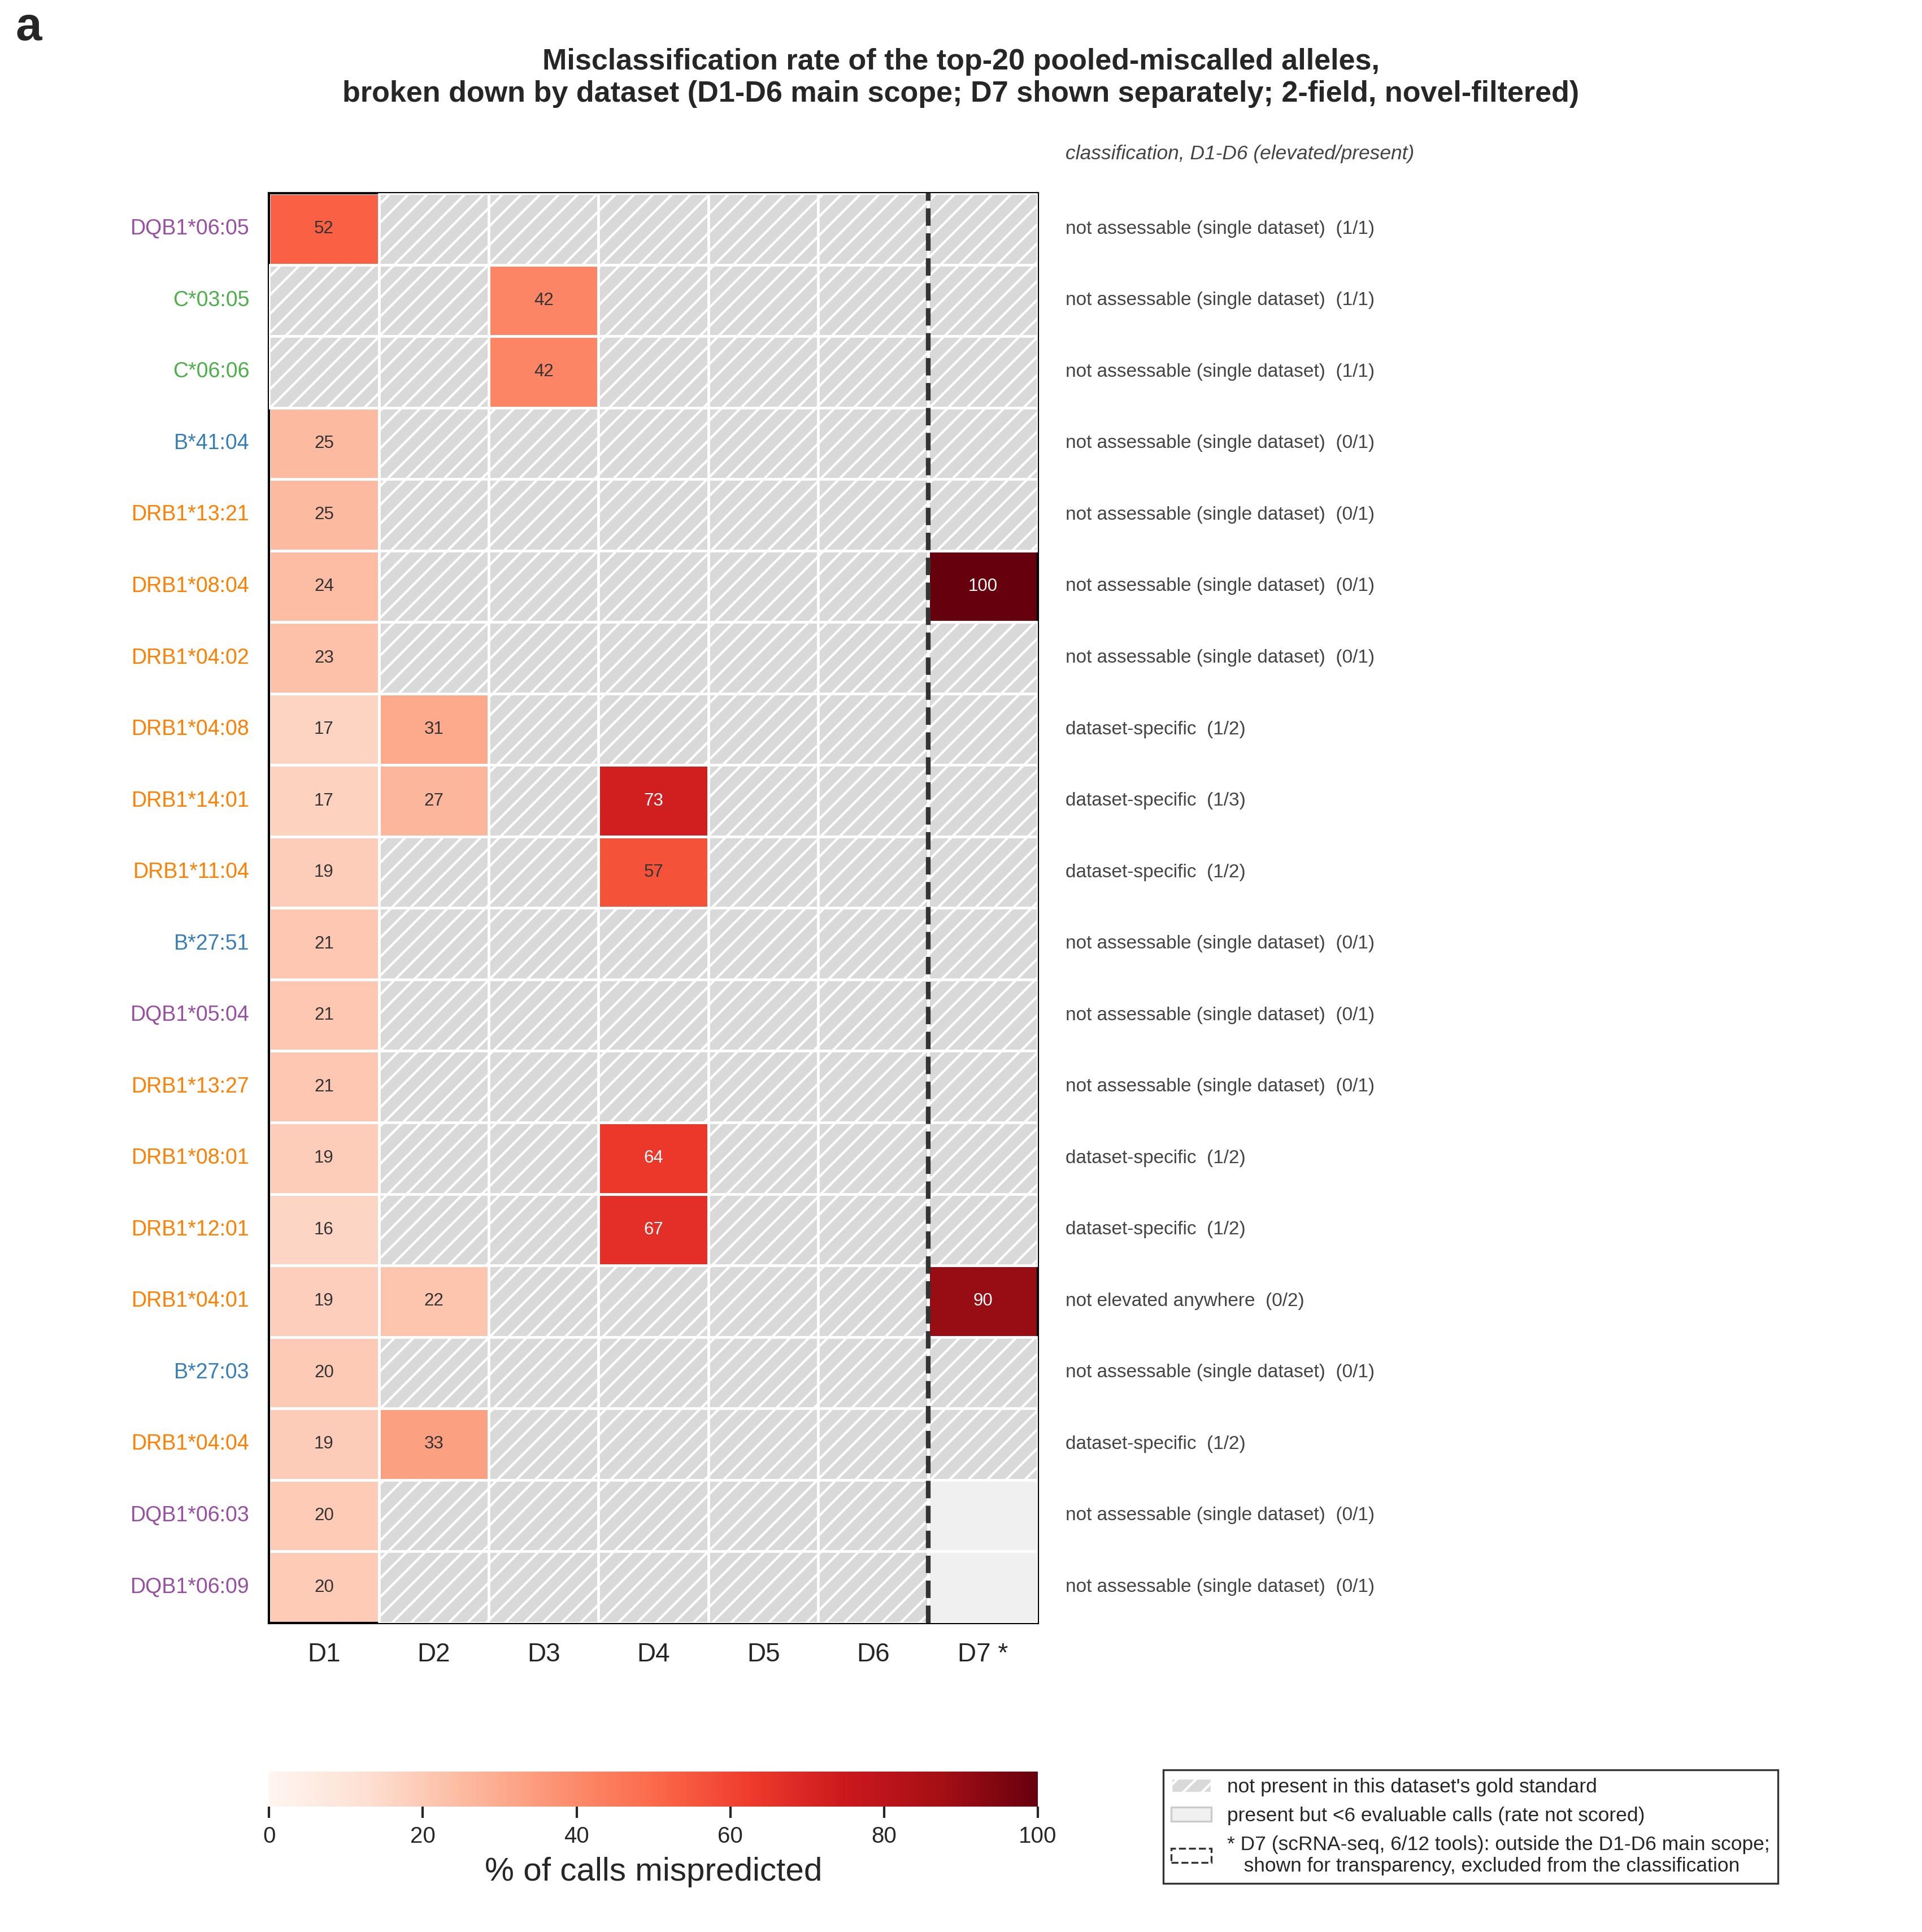

In [8]:
# ---- panel a ----
path_a = os.path.join(FIG_DIR, "fig7_supp_a_heatmap.png")
plot_heatmap(wide_rate, wide_total, presence_wide, order_desc, locus_of,
            classif, datasets, path_a, scope_label)
show(path_a)


panel b: 8/20 alleles scorable in >=2 datasets -> ['DRB1*08:04', 'DRB1*04:08', 'DRB1*14:01', 'DRB1*11:04', 'DRB1*08:01', 'DRB1*12:01', 'DRB1*04:01', 'DRB1*04:04']


  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_b_small_multiples.png


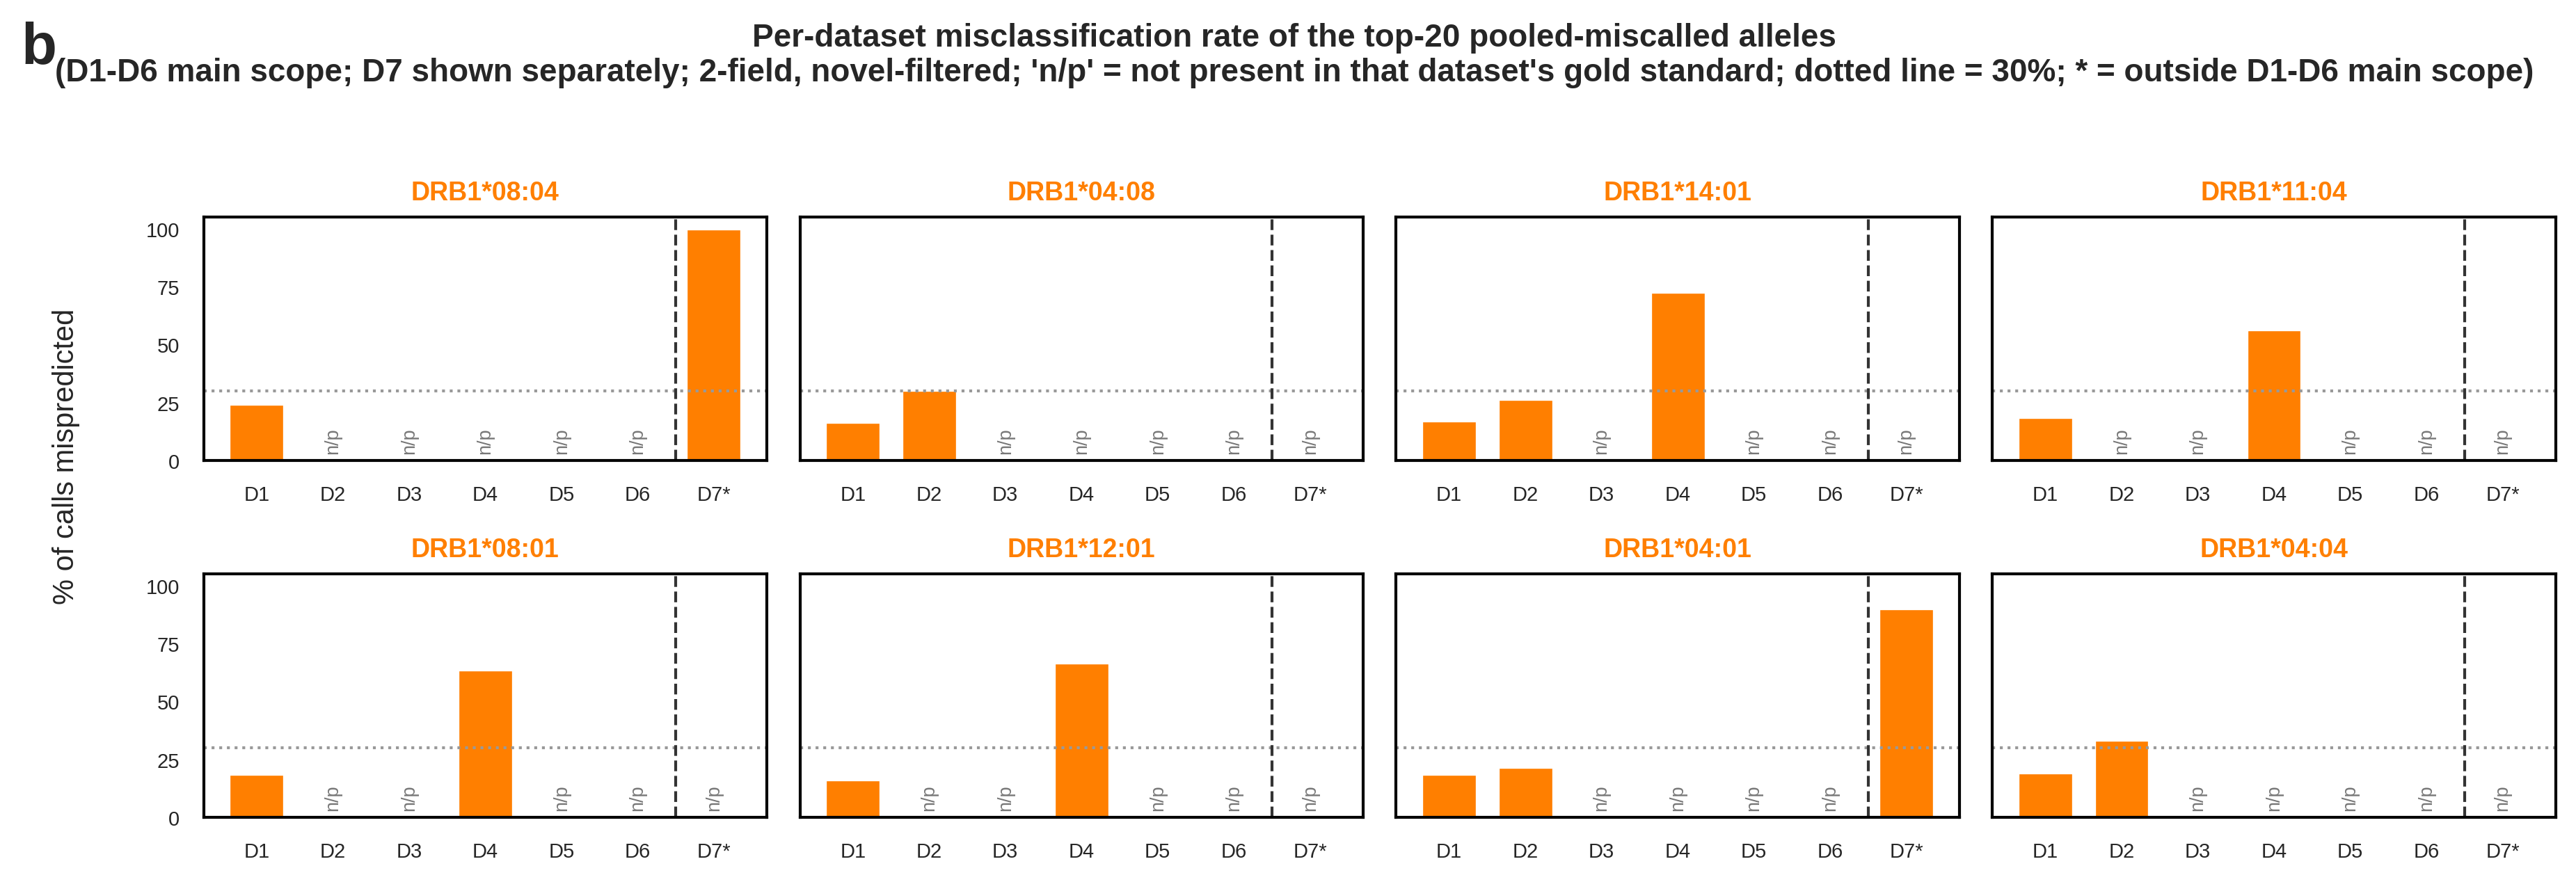

In [9]:
# ---- panel b -- restricted to alleles scorable (>=MIN_TOTAL evaluable calls)
# in >=2 datasets: for the rest, "dataset-specific vs universal" isn't an
# answerable question, so including them just clutters the panel. Display-only
# filter -- order_desc/panel a/tables are unaffected.
n_scorable = {a: sum(1 for ds in datasets if wide_total.get((a, ds), 0) >= MIN_TOTAL)
             for a in order_desc}
order_b = [a for a in order_desc if n_scorable[a] >= 2]
print(f"panel b: {len(order_b)}/{len(order_desc)} alleles scorable in >=2 datasets -> {order_b}")

path_b = os.path.join(FIG_DIR, "fig7_supp_b_small_multiples.png")
plot_small_multiples(wide_rate, wide_total, presence_wide, order_b, locus_of,
                     datasets, path_b, scope_label)
show(path_b)


## Panel c — each dataset's own independent top-N ranking

Migrated from the deleted `fig7_per_dataset_top_alleles.py`. Reads the
`allele_miscall_by_dataset.csv` written above (no rescoring) and re-ranks
each dataset independently. One standalone figure per dataset (see
`Figures/miscalled_alleles_family_README.md` §2d for why this isn't one
combined panel).

In [10]:
TALLY_CSV = os.path.join(OUT_DIR, "allele_miscall_by_dataset.csv")
N_MAX = 20   # the original Figure 7's N


def load_tally(path: str = TALLY_CSV) -> pd.DataFrame:
    df = pd.read_csv(path)
    need = {"Dataset", "Locus", "Allele", "Total", "Mis", "MisclassificationRate%"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")
    recomputed = 100.0 * df["Mis"] / df["Total"]
    if not np.allclose(recomputed, df["MisclassificationRate%"], atol=1e-6):
        raise AssertionError(f"{path} is internally inconsistent: rate != 100*Mis/Total.")
    if (df["Mis"] > df["Total"]).any():
        raise AssertionError(f"{path}: Mis > Total for some rows.")
    return df


def top_n_for_dataset(df: pd.DataFrame, ds: int,
                      n_max: int = N_MAX, min_total: int = MIN_TOTAL) -> pd.DataFrame:
    """That dataset's OWN ranking: rank only its own rows, by its own rate.
    Deterministic tie-break (rate desc, Total desc, Allele asc)."""
    sub = df[(df["Dataset"] == ds) & (df["Total"] >= min_total)].copy()
    sub = sub.sort_values(["MisclassificationRate%", "Total", "Allele"],
                          ascending=[False, False, True])
    n = min(n_max, len(sub))
    out = sub.head(n).reset_index(drop=True)
    out["RankInDataset"] = np.arange(1, len(out) + 1)
    return out


In [11]:
# Layout packed in INCHES so one bar is the same physical height in every
# dataset's figure -- a 2-bar chart and a 20-bar chart use the same bar scale.
BAR_H = 0.22
COL_W = 4.75
AX_LEFT_IN = 1.30
AX_RIGHT_IN = 0.55
FIG_TOP_SINGLE = 0.30   # title only (subtitle removed 2026-07-23)
XLABEL_TICKS_IN = 0.45
LEGEND_GAP_IN = 0.12
LEGEND_BLOCK_IN = 0.40
BOTTOM_MARGIN_IN = 0.10
FIG_BOT_SINGLE = XLABEL_TICKS_IN + LEGEND_GAP_IN + LEGEND_BLOCK_IN + BOTTOM_MARGIN_IN


def plot_single_dataset(ds: int, d, path: str):
    """Panel c, one dataset. Original Figure 7's bar-chart grammar, ranked on
    that dataset's own data only."""
    apply_theme()
    n = len(d)
    reduced = REDUCED_COVERAGE.get(ds)

    fig_h = n * BAR_H + FIG_TOP_SINGLE + FIG_BOT_SINGLE
    fig_w = COL_W
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax_x0 = AX_LEFT_IN / fig_w
    ax_w = (COL_W - AX_LEFT_IN - AX_RIGHT_IN) / fig_w
    ax_h = (n * BAR_H) / fig_h
    ax_y0 = FIG_BOT_SINGLE / fig_h
    ax = fig.add_axes([ax_x0, ax_y0, ax_w, ax_h])

    dd = d.sort_values(["MisclassificationRate%", "Total", "Allele"],
                       ascending=[True, True, False]).reset_index(drop=True)
    ypos = np.arange(len(dd))
    colors = [LOCUS_PAL.get(L, "#888888") for L in dd["Locus"]]
    ax.barh(ypos, dd["MisclassificationRate%"], color=colors, height=0.72)

    for y, (rate, mis, tot) in enumerate(
            zip(dd["MisclassificationRate%"], dd["Mis"], dd["Total"])):
        if rate > 86:
            ax.text(rate - 1.5, y, f"{int(mis)}/{int(tot)}", va="center",
                    ha="right", fontsize=6.5, color="white")
        else:
            ax.text(rate + 1.5, y, f"{int(mis)}/{int(tot)}", va="center",
                    ha="left", fontsize=6.5, color="#666666")

    ax.set_yticks(ypos)
    ax.set_yticklabels(dd["Allele"], fontsize=8)
    for tick, L in zip(ax.get_yticklabels(), dd["Locus"]):
        tick.set_color(LOCUS_PAL.get(L, "#000000"))
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.7, len(dd) - 0.3)
    ax.set_xlabel("% of calls mispredicted", fontsize=9.5)
    ax.tick_params(axis="x", labelsize=8.5)
    ax.set_ylabel("")

    title = f"D{ds} — Top {n} Most-Frequently Miscalled Alleles"
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=14,
                color="#000000" if reduced is None else "#7a4a00")
    full_box(ax)

    handles = [mpatches.Patch(facecolor=LOCUS_PAL[L], label=L) for L in LOCI]
    legend_y = BOTTOM_MARGIN_IN / fig_h
    fig.legend(handles=handles, title="Locus", loc="lower center",
               bbox_to_anchor=(0.5, legend_y), ncol=len(LOCI),
               fontsize=8.5, title_fontsize=9, **LEGEND_KWARGS)

    fig.savefig(path, dpi=300, bbox_inches="tight")
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")


  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_c_D1.png


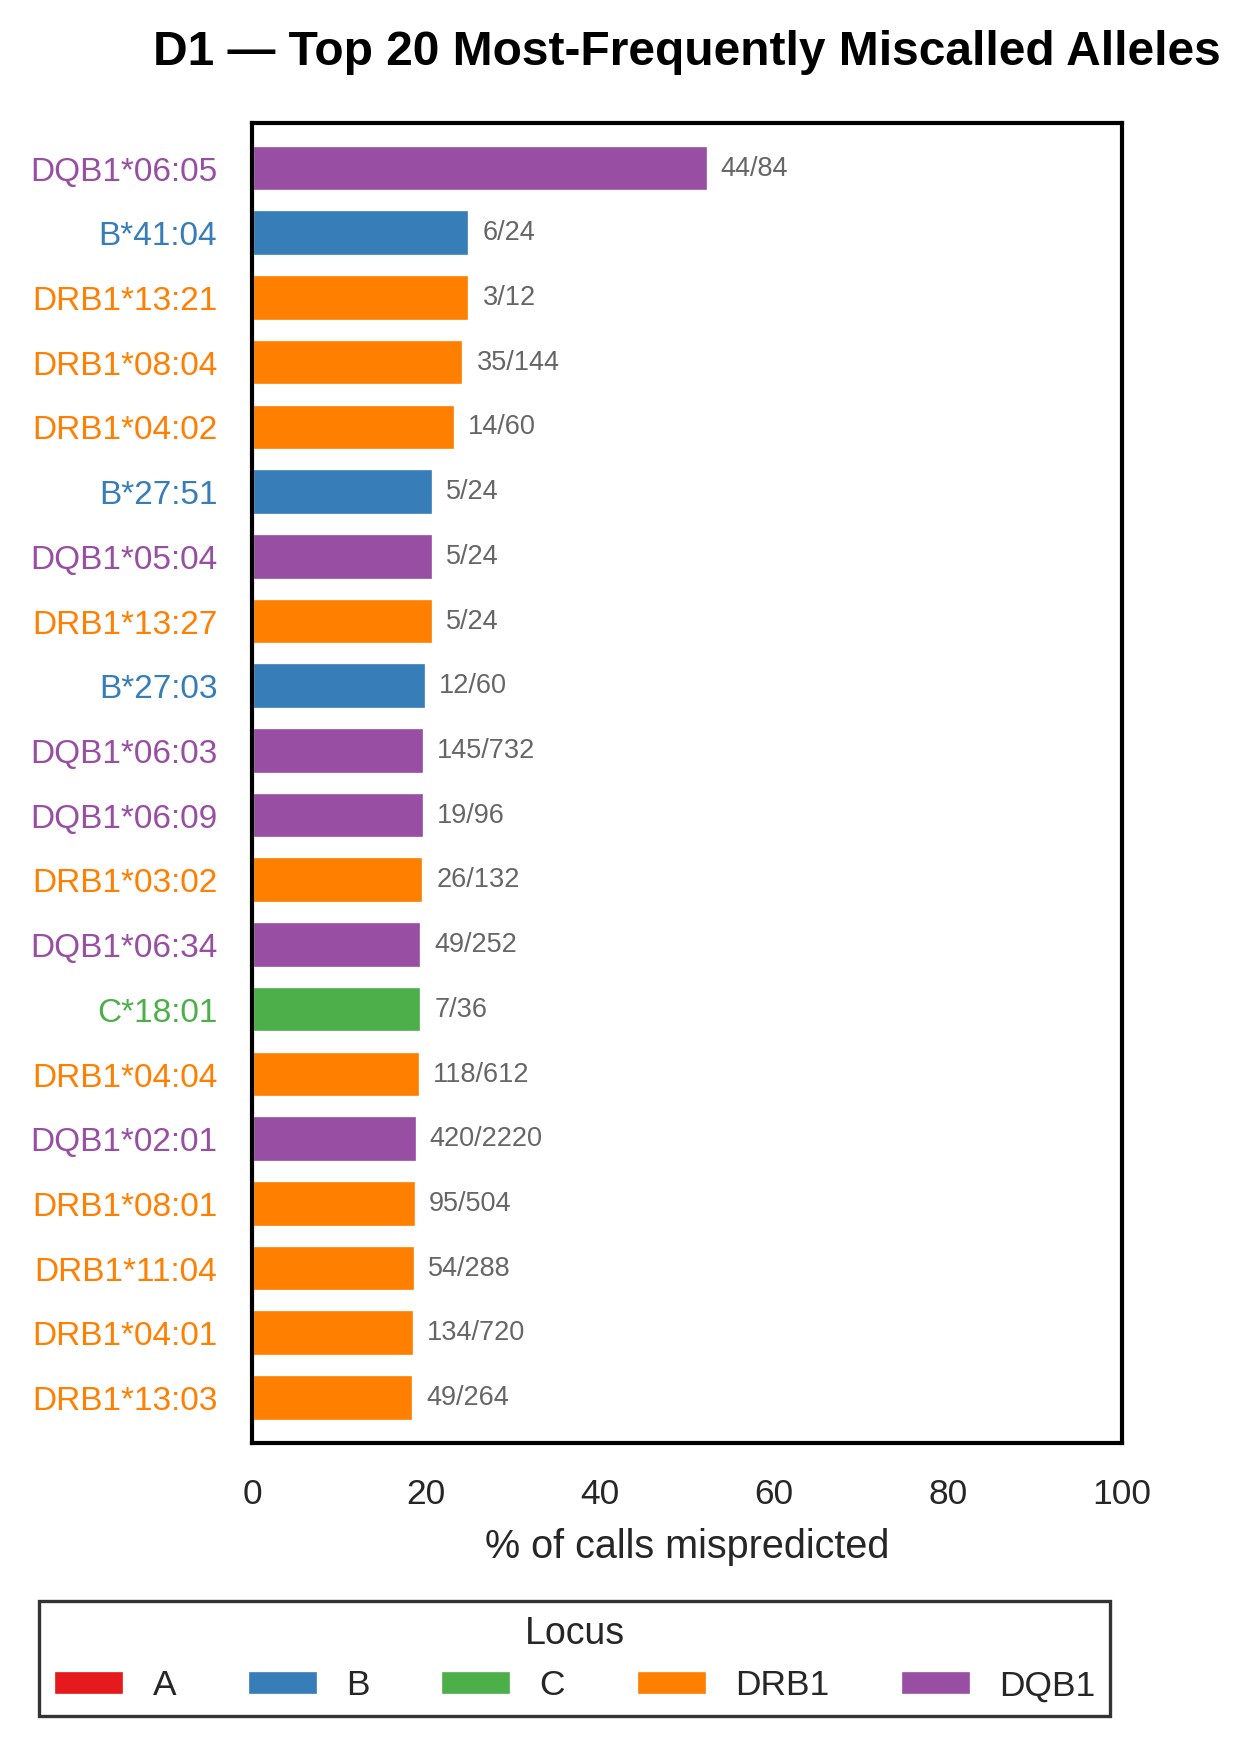

  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_c_D2.png


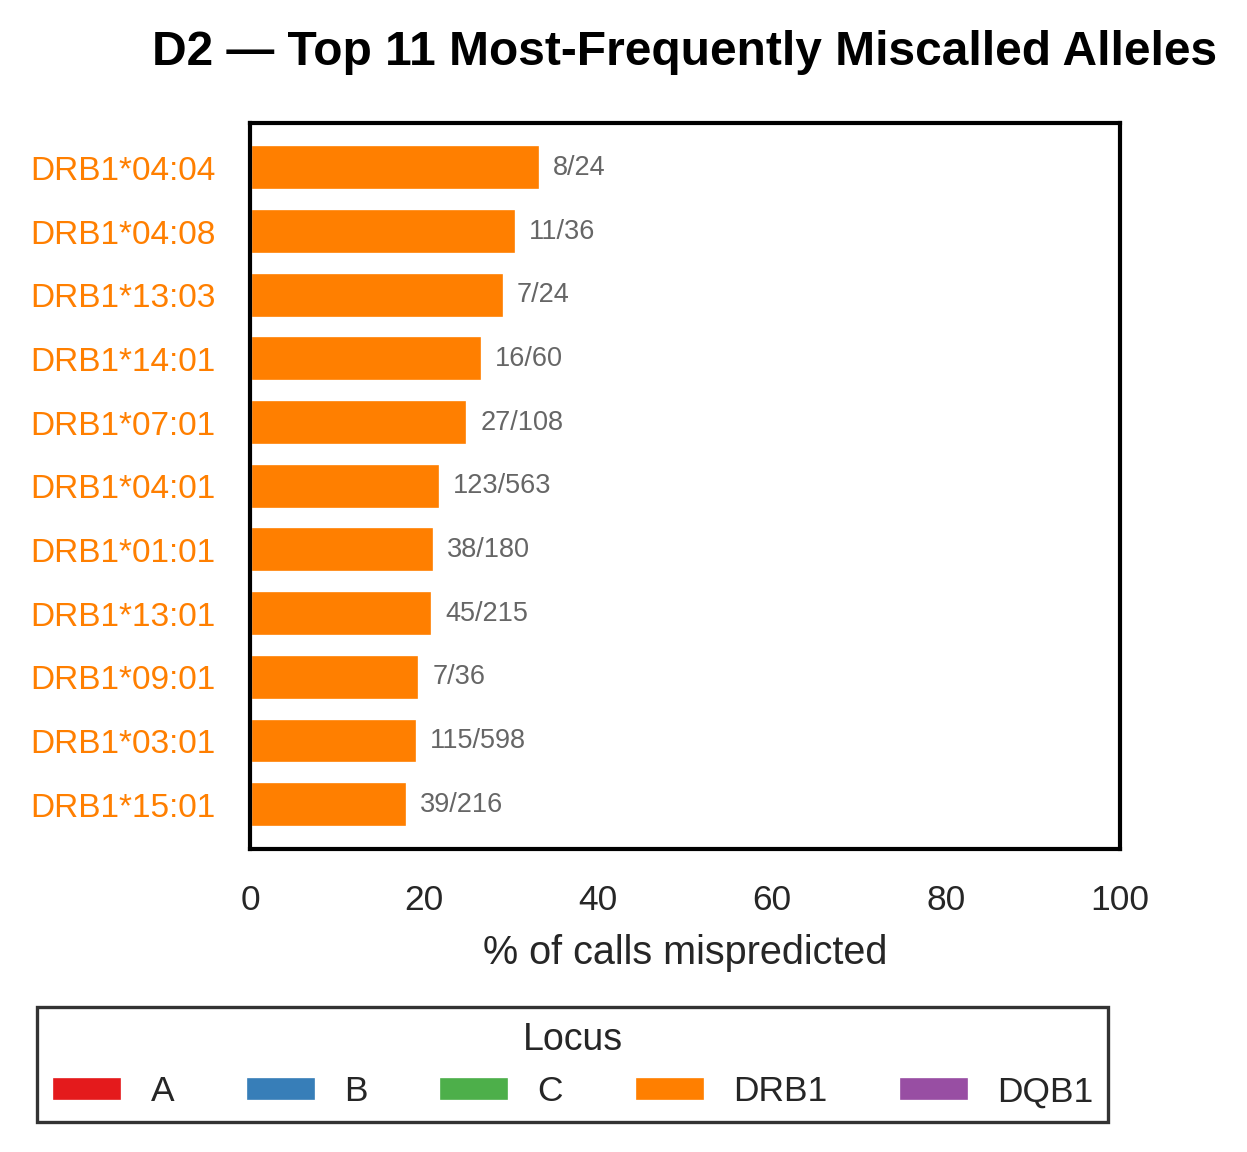

  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_c_D3.png


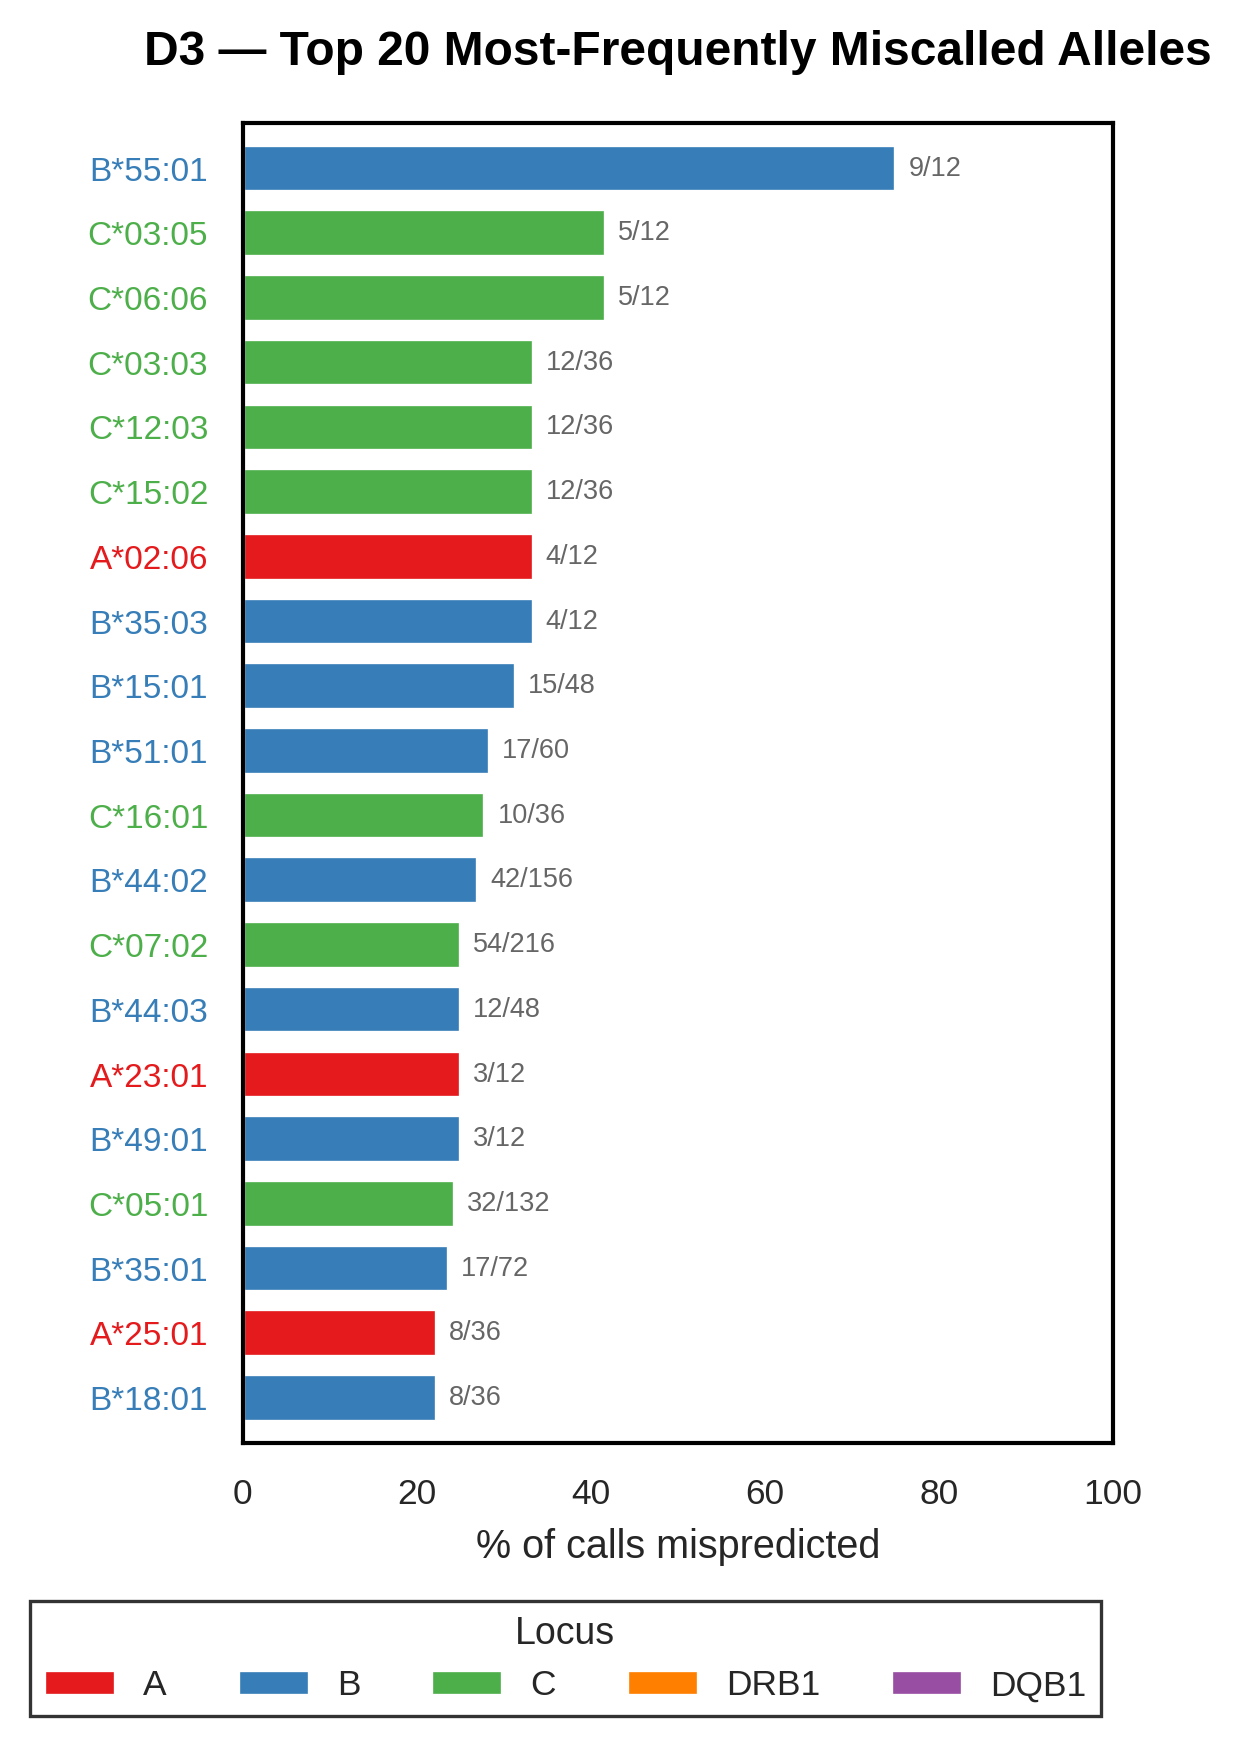

  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_c_D4.png


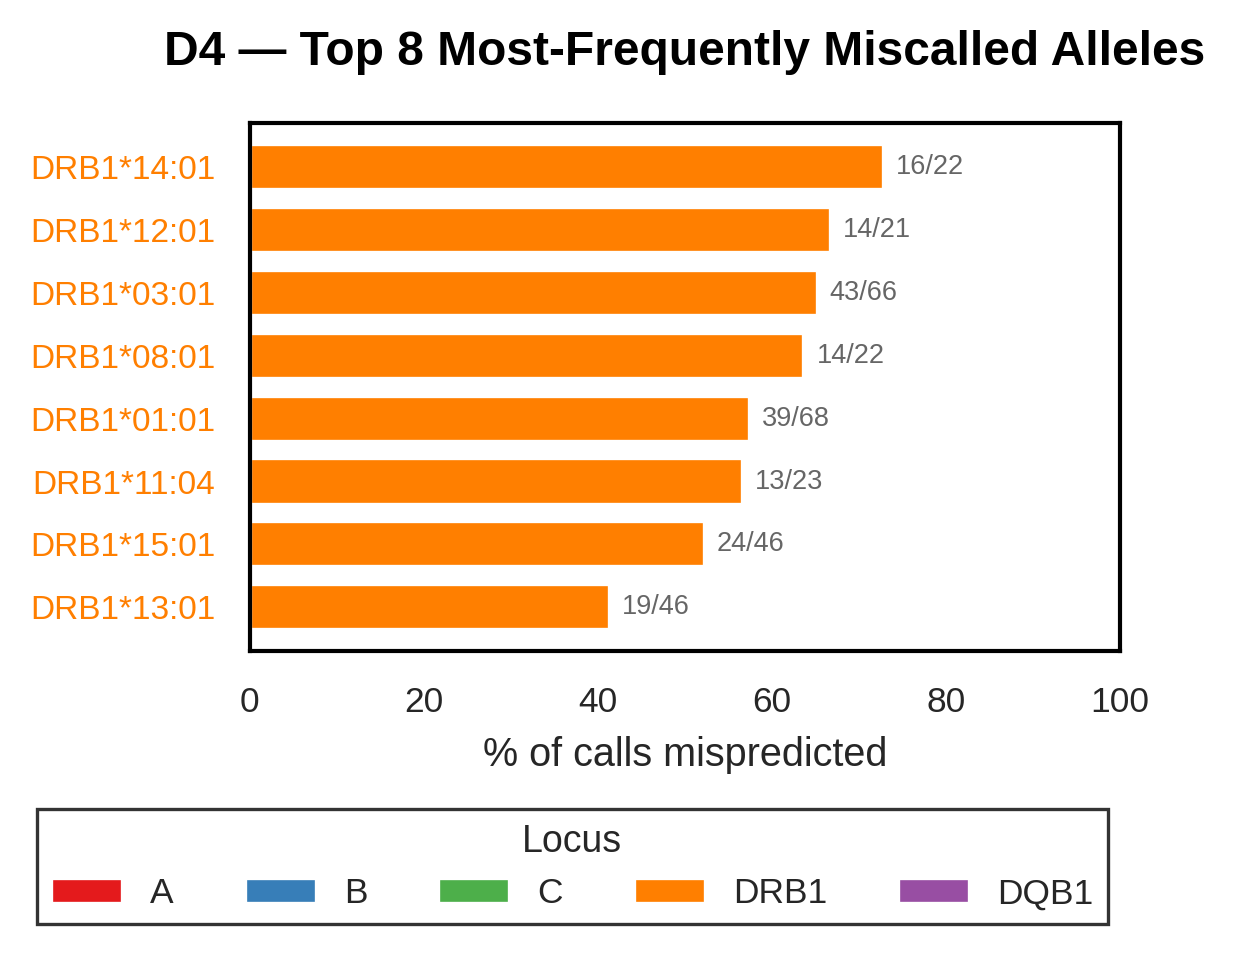

  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_c_D5.png


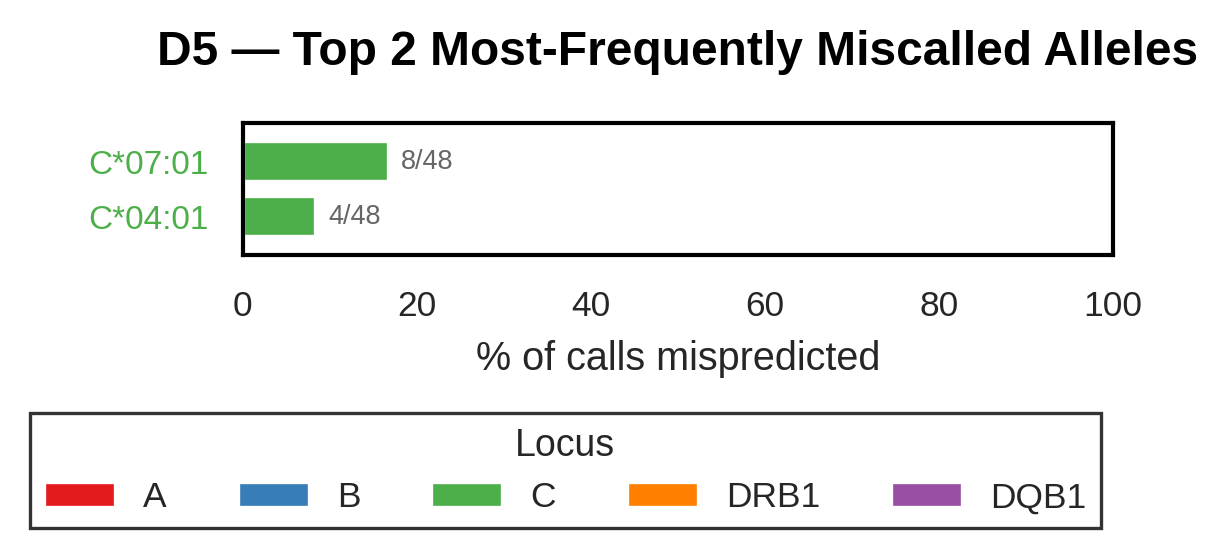

  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_c_D6.png


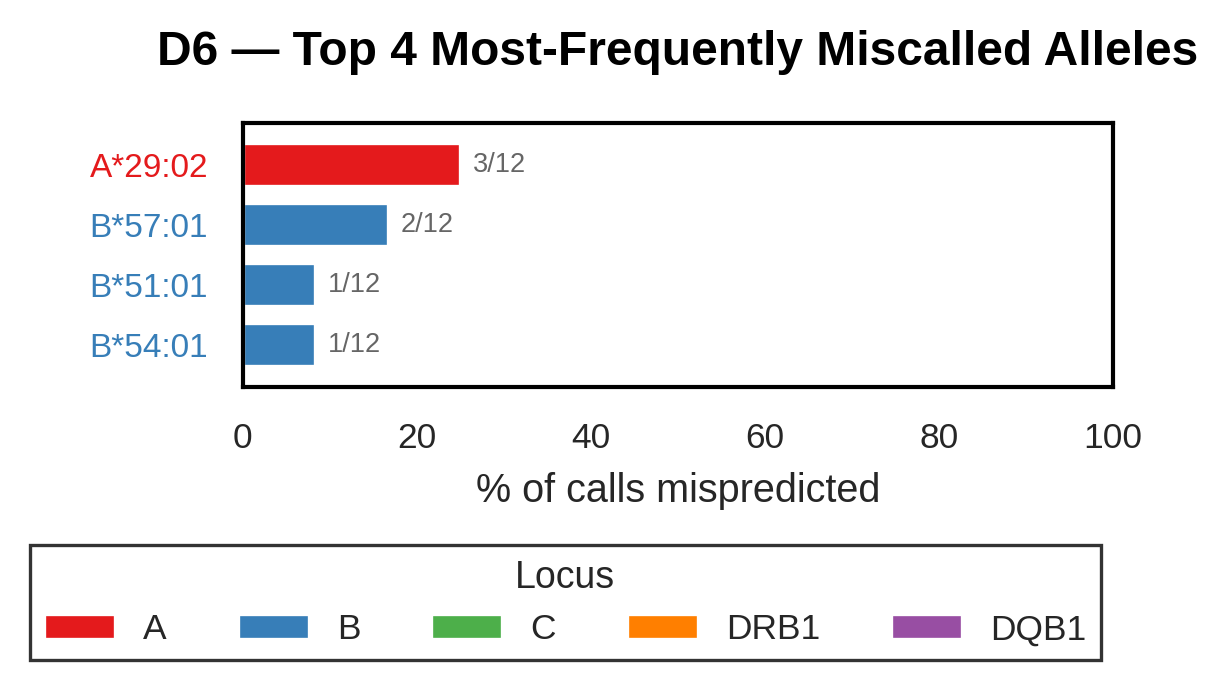

  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_c_D7.png


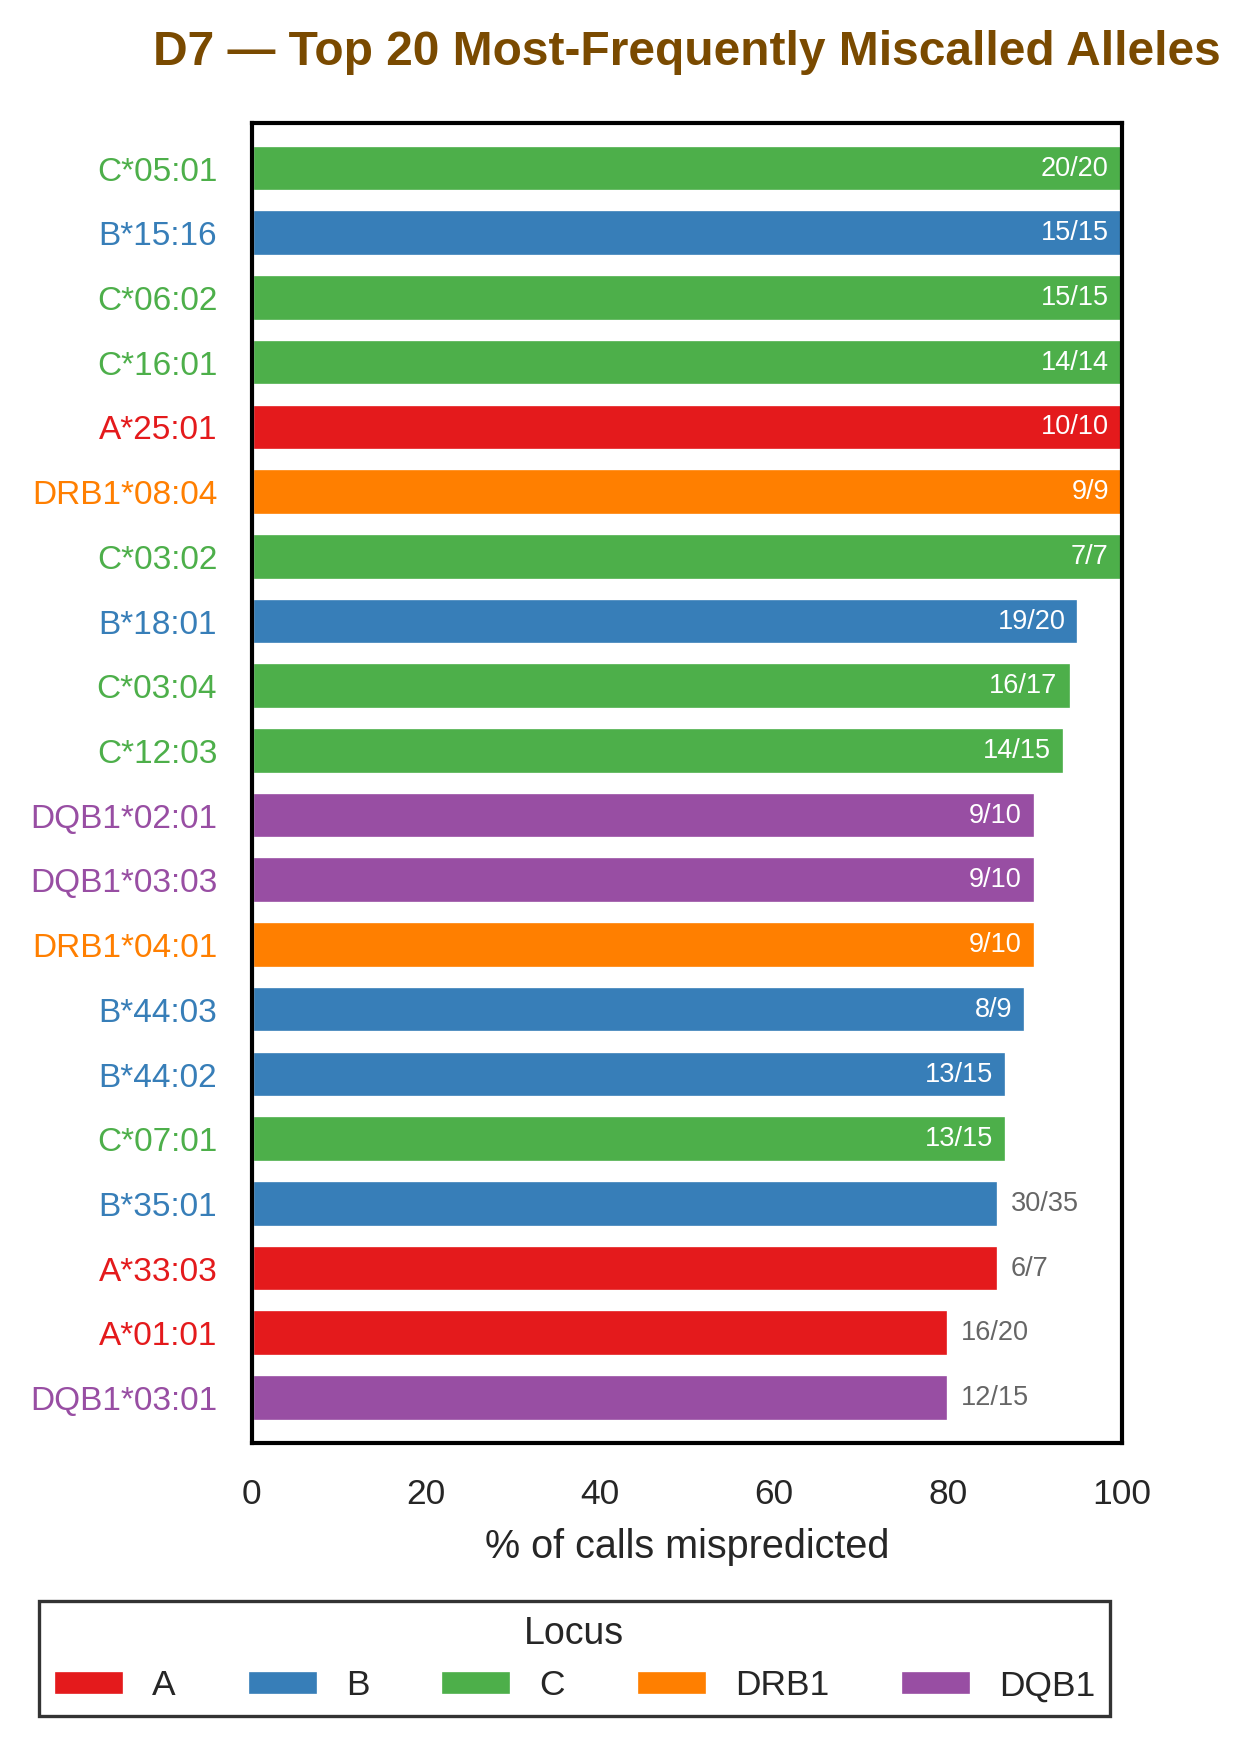

In [12]:
df_c = load_tally()

tops = {ds: top_n_for_dataset(df_c, ds, N_MAX, MIN_TOTAL) for ds in DISPLAY_SCOPE}

for ds in DISPLAY_SCOPE:
    if len(tops[ds]) == 0:
        print(f"D{ds}: no rankable alleles -- skipped")
        continue
    path_c = os.path.join(FIG_DIR, f"fig7_supp_c_D{ds}.png")
    plot_single_dataset(ds, tops[ds], path_c)
    show(path_c, width=700)


In [13]:
# ---- panel c side tables (recurrence across datasets' own top-N lists) ----
plotted = pd.concat(
    [t.assign(InMainScope=(ds in MAIN_SCOPE),
              ToolCoverage=REDUCED_COVERAGE.get(ds, "12/12 tools"))
     for ds, t in tops.items() if len(t)],
    ignore_index=True)
cols = ["Dataset", "InMainScope", "ToolCoverage", "RankInDataset", "Locus",
        "Allele", "Total", "Mis", "MisclassificationRate%", "GSSlots", "GSSamples"]
plotted = plotted[[c for c in cols if c in plotted.columns]]
p_plotted = os.path.join(OUT_DIR, "allele_miscall_top_per_dataset_own_ranking.csv")
plotted.to_csv(p_plotted, index=False)

main_tops = {ds: tops[ds] for ds in MAIN_SCOPE if len(tops[ds])}
in_top = {}
for ds, t in main_tops.items():
    for r in t.itertuples():
        in_top.setdefault(r.Allele, []).append(ds)

rankable_in = {}
for ds in MAIN_SCOPE:
    sub = df_c[(df_c["Dataset"] == ds) & (df_c["Total"] >= MIN_TOTAL)]
    for a in sub["Allele"]:
        rankable_in.setdefault(a, []).append(ds)

rec_rows = []
for a, dss in sorted(in_top.items()):
    rec_rows.append({
        "Allele": a,
        "Locus": plotted.loc[plotted["Allele"] == a, "Locus"].iloc[0],
        "NDatasetsInOwnTopN_D1toD6": len(dss),
        "DatasetsInOwnTopN": "+".join(f"D{d}" for d in sorted(dss)),
        "NDatasetsRankable_D1toD6": len(rankable_in.get(a, [])),
        "DatasetsRankable": "+".join(f"D{d}" for d in sorted(rankable_in.get(a, []))),
        "Recurring": len(dss) >= 2,
        "HadTheOpportunity": len(rankable_in.get(a, [])) >= 2,
    })
rec = pd.DataFrame(rec_rows).sort_values(
    ["NDatasetsInOwnTopN_D1toD6", "Allele"], ascending=[False, True])
p_rec = os.path.join(OUT_DIR, "allele_miscall_recurring_across_own_topN.csv")
rec.to_csv(p_rec, index=False)

print(f"wrote {p_plotted}\nwrote {p_rec}")
print(f"Union of D1-D6 own-top-N lists: {len(rec)} distinct alleles; "
     f"{int(rec['Recurring'].sum())} recurring in >=2 datasets.")


wrote /home/nicolaedrabcinski/hla_benchmarking/repo/results/allele_miscall_top_per_dataset_own_ranking.csv
wrote /home/nicolaedrabcinski/hla_benchmarking/repo/results/allele_miscall_recurring_across_own_topN.csv
Union of D1-D6 own-top-N lists: 54 distinct alleles; 11 recurring in >=2 datasets.


## Panels d, e — grouped bars / slope plot, cross-dataset comparison

Migrated from the deleted `fig7_miscall_variants.py`. No scoring — reads the
CSVs panels a/b already wrote.

In [14]:
# Dataset encoding for panel d: a single-hue ORDINAL ramp (light->dark =
# D1->D7) -- datasets are an ordered axis, and one hue keeps this categorically
# distinct from the multi-hue locus palette.
DATASET_COLORS = {d: c for d, c in zip(
    DISPLAY_SCOPE, sns.color_palette("Blues", n_colors=len(DISPLAY_SCOPE) + 2)[2:])}
LOW_N_EDGE = "#999999"


def load_de():
    brk = pd.read_csv(os.path.join(OUT_DIR, "allele_miscall_top20_by_dataset.csv"))
    cls = pd.read_csv(os.path.join(OUT_DIR, "allele_miscall_top20_classification.csv"))
    order = list(cls["Allele"])
    locus_of = dict(zip(cls["Allele"], cls["Locus"]))
    pooled = dict(zip(cls["Allele"], cls["PooledMisclassificationRate%"]))
    return brk, order, locus_of, pooled


In [15]:
def plot_variant1(brk, order, locus_of, pooled, path):
    """Panel d. Horizontal grouped/clustered bars -- one cluster per allele,
    one sub-bar per dataset in which it is scorable. Locus reads down the
    row-label column (text color + left-margin swatch); dataset reads as bar
    fill (ordinal ramp); the pooled D1-D6 rate (the ranking basis, 2026-07-24
    -- see SCOPE DECISION in the orchestration cell above) is a thin grey
    reference tick per row."""
    apply_theme()
    rows = [a for a in order]
    n = len(rows)

    # Legend lives in a two-row block below the axes, sized in inches so it
    # works for any n.
    old_fig_h = 0.62 * n + 2.9
    LEGEND_IN = 0.85
    fig_h = old_fig_h + LEGEND_IN
    bottom_gap_in = 0.085 * old_fig_h
    top_gap_in = (1 - 0.930) * old_fig_h
    ax_bottom = (bottom_gap_in + LEGEND_IN) / fig_h
    ax_top = 1 - top_gap_in / fig_h
    fig = plt.figure(figsize=(13.6, fig_h))
    ax = fig.add_axes([0.20, ax_bottom, 0.76, ax_top - ax_bottom])

    bar_h = 0.74
    any_low_n = False

    for i, allele in enumerate(rows):
        sub = brk[brk["Allele"] == allele]
        scored = sub[sub["State"] == "scored"]
        lown = sub[sub["State"] == "present, too few evaluable calls"]
        present = pd.concat([scored, lown]).sort_values("Dataset")
        k = len(present)
        if k == 0:
            continue
        h = min(bar_h / k, 0.20)
        offs = (np.arange(k) - (k - 1) / 2.0) * h

        for (off, (_, r)) in zip(offs, present.iterrows()):
            ds = int(r["Dataset"])
            y = i + off
            if r["State"] == "scored":
                val = float(r["MisclassificationRate%"])
                ax.barh(y, val, height=h * 0.92, color=DATASET_COLORS[ds],
                        edgecolor="#3a3a3a" if ds not in MAIN_SCOPE else "none",
                        linewidth=1.1 if ds not in MAIN_SCOPE else 0,
                        linestyle="--" if ds not in MAIN_SCOPE else "-", zorder=3)
                lab = (f"D{ds}{'*' if ds not in MAIN_SCOPE else ''} "
                       f"{val:.0f} (n={int(r['Total'])})")
                if val > 78:
                    ax.text(val - 0.9, y, lab, va="center", ha="right", fontsize=6.6,
                            color="white", zorder=4)
                else:
                    ax.text(val + 0.9, y, lab, va="center", ha="left", fontsize=6.6,
                            color="#444444", zorder=4)
            else:
                any_low_n = True
                ax.barh(y, 2.0, height=h * 0.92, facecolor="none",
                        edgecolor=LOW_N_EDGE, linewidth=0.7, linestyle=":", zorder=2)
                ax.text(3.0, y, f"D{ds}{'*' if ds not in MAIN_SCOPE else ''}: "
                                f"present, n={int(r['Total'])}<{MIN_TOTAL} — rate not scored",
                        va="center", ha="left", fontsize=6.4, style="italic",
                        color="#8a8a8a", zorder=4)

        ax.plot([pooled[allele]] * 2, [i - bar_h / 2, i + bar_h / 2],
                color="#666666", lw=1.3, ls=(0, (2, 1.6)), zorder=5)

    ax.axvline(ELEVATED_THRESHOLD, color="#c0392b", lw=1.1, ls=":", zorder=1)
    ax.text(ELEVATED_THRESHOLD, n - 0.35, f" {ELEVATED_THRESHOLD:.0f}% 'elevated'",
            fontsize=7.5, color="#c0392b", va="bottom", ha="left")

    ax.set_yticks(range(n))
    ax.set_yticklabels(rows)
    for tick in ax.get_yticklabels():
        tick.set_color(LOCUS_PAL.get(locus_of.get(tick.get_text(), ""), "#000000"))
        tick.set_fontsize(9.5)
        tick.set_fontweight("bold")
    ax.tick_params(axis="y", length=0, pad=24)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xlabel("% of calls mispredicted")
    ax.tick_params(axis="x", labelsize=9)
    full_box(ax)

    for i, allele in enumerate(rows):
        ax.add_patch(mpatches.Rectangle(
            (-3.4, i - bar_h / 2), 1.9, bar_h, transform=ax.transData,
            facecolor=LOCUS_PAL.get(locus_of[allele], "#888888"),
            edgecolor="none", clip_on=False, zorder=6))

    ds_handles = [mpatches.Patch(facecolor=DATASET_COLORS[d], edgecolor="none",
                                 label=f"D{d}" + (" *" if d not in MAIN_SCOPE else ""))
                  for d in DISPLAY_SCOPE]
    loc_handles = [mpatches.Patch(facecolor=LOCUS_PAL[L], edgecolor="none", label=L)
                   for L in LOCI]
    extra = [mlines.Line2D([], [], color="#666666", lw=1.3, ls=(0, (2, 1.6)),
                           label="pooled rate (D1-D6; ranking basis, 2026-07-24)")]
    if any_low_n:
        extra.append(mpatches.Patch(facecolor="none", edgecolor=LOW_N_EDGE, ls=":",
                                    label=f"present but <{MIN_TOTAL} evaluable calls\n(rate not scored)"))

    row1_y = (LEGEND_IN * 0.62) / fig_h
    row2_y = (LEGEND_IN * 0.14) / fig_h
    leg1 = fig.legend(handles=ds_handles, title="Dataset (bar fill)",
                      loc="lower center", bbox_to_anchor=(0.5, row1_y),
                      ncol=len(ds_handles), fontsize=8,
                      title_fontsize=8.5, **LEGEND_KWARGS)
    fig.legend(handles=loc_handles + extra, title="Locus (row label & swatch)",
              loc="lower center", bbox_to_anchor=(0.5, row2_y),
              ncol=len(loc_handles) + len(extra), fontsize=7.6,
              title_fontsize=8.5, **LEGEND_KWARGS)
    fig.add_artist(leg1)

    fig.suptitle(
        "Per-dataset misclassification rate of the top-20 pooled-miscalled alleles\n"
        "(2-field, novel-filtered; one bar per dataset in which the allele is scorable;\n"
        "* D7 = scRNA-seq, 6/12 tools, outside the D1-D6 main scope)",
        fontsize=11.5, fontweight="bold", y=0.988)
    add_panel_label(fig, "d")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")


In [16]:
def plot_variant2(brk, order, locus_of, path):
    """Panel e. Slope/dot plot: x = dataset, y = % miscalled. Color encodes
    LOCUS only; allele identity is carried by direct labels (legible because
    the data are sparse -- only a handful of the 20 alleles are scorable in
    more than one dataset). Segments join ONLY adjacent scored datasets --
    never interpolated across an absent one."""
    apply_theme()
    fig = plt.figure(figsize=(11.5, 7.4))
    ax = fig.add_axes([0.075, 0.165, 0.70, 0.735])

    multi, single, lown_pts = [], [], []
    for allele in order:
        sub = brk[(brk["Allele"] == allele) & (brk["State"] == "scored")]
        sub = sub.sort_values("Dataset")
        pts = [(int(r["Dataset"]), float(r["MisclassificationRate%"]), int(r["Total"]))
               for _, r in sub.iterrows()]
        if len(pts) >= 2:
            multi.append((allele, pts))
        elif len(pts) == 1:
            single.append((allele, pts))
        low = brk[(brk["Allele"] == allele) &
                  (brk["State"] == "present, too few evaluable calls")]
        for _, r in low.iterrows():
            lown_pts.append((allele, int(r["Dataset"]), int(r["Total"])))

    def col(a):
        return LOCUS_PAL.get(locus_of.get(a, ""), "#888888")

    n_with_segment = 0
    no_segment = set()
    for allele, pts in multi:
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        c = col(allele)
        drew = False
        for (x0, y0, _), (x1, y1, _) in zip(pts, pts[1:]):
            if x1 - x0 == 1:
                ax.plot([x0, x1], [y0, y1], color=c, lw=2.1, alpha=0.85,
                        solid_capstyle="round", zorder=3)
                drew = True
        n_with_segment += int(drew)
        if not drew:
            no_segment.add(allele)
        ax.scatter(xs, ys, s=52, color=c, edgecolor="white", lw=1.1, zorder=4)

    for allele, pts in single:
        x, y, _ = pts[0]
        ax.scatter([x], [y], s=46, color=col(allele), edgecolor="white", lw=1.1,
                   marker="o", zorder=4, alpha=0.95)

    used = {}

    def place(x, y, text, colr, weight, fs, ha="left", dx=0.09):
        ys = used.setdefault(round(x, 3), [])
        yy = y
        step = 2.4
        guard = 0
        while any(abs(yy - v) < step for v in ys) and guard < 80:
            yy += step
            guard += 1
        ys.append(yy)
        ax.annotate(text, xy=(x, y), xytext=(x + dx, yy),
                    fontsize=fs, color=colr, va="center", ha=ha,
                    fontweight=weight, zorder=6,
                    arrowprops=dict(arrowstyle="-", lw=0.5, color=colr, alpha=0.55,
                                    shrinkA=0, shrinkB=2)
                    if abs(yy - y) > 0.8 else None)

    for allele, pts in multi:
        targets = pts if allele in no_segment else [pts[-1]]
        for (x, y, _) in targets:
            place(x, y, f" {allele}", col(allele), "bold", 8.4)
    for allele, pts in single:
        x, y, _ = pts[0]
        place(x, y, f" {allele}", col(allele), "normal", 7.6)

    if lown_pts:
        by_ds = {}
        for allele, ds, tot in lown_pts:
            by_ds.setdefault(ds, []).append(f"{allele} (n={tot})")
        parts = "; ".join(f"D{ds}: " + ", ".join(v) for ds, v in sorted(by_ds.items()))
        fig.text(0.075, 0.012,
                 f"Present in the gold standard but with <{MIN_TOTAL} evaluable calls, so no "
                 f"rate is scored and no point is plotted —\n{parts}.",
                 fontsize=7.4, color="#8a8a8a", style="italic", ha="left", va="bottom")

    ax.axhline(ELEVATED_THRESHOLD, color="#c0392b", lw=1.1, ls=":", zorder=1)
    ax.text(7.55, ELEVATED_THRESHOLD + 1.2, f"{ELEVATED_THRESHOLD:.0f}% 'elevated'",
            fontsize=8, color="#c0392b", va="bottom", ha="right")

    ax.axvline(6.5, color="#333333", lw=1.8, ls="--", zorder=2)
    ax.text(6.55, 97, "D7: outside\nD1-D6 main scope", fontsize=7.6,
            color="#333333", va="top", ha="left", style="italic")

    ax.set_xticks(DISPLAY_SCOPE)
    ax.set_xticklabels([f"D{d}" + ("\n*" if d not in MAIN_SCOPE else "")
                        for d in DISPLAY_SCOPE], fontsize=11)
    ax.set_xlim(0.6, 7.6)
    ax.set_ylim(-2, 102)
    ax.set_yticks(range(0, 101, 10))
    ax.set_ylabel("% of calls mispredicted")
    ax.set_xlabel("Dataset")
    ax.tick_params(axis="y", labelsize=9)
    full_box(ax)

    loc_handles = [mlines.Line2D([], [], color=LOCUS_PAL[L], marker="o", lw=2.1,
                                 markersize=7, markeredgecolor="white", label=L)
                   for L in LOCI]
    shape_handles = [
        mlines.Line2D([], [], color="#555555", marker="o", lw=2.1, markersize=7,
                      markeredgecolor="white",
                      label=f"joined by a segment ({n_with_segment} alleles):\n"
                            "scorable in two ADJACENT datasets"),
        mlines.Line2D([], [], color="none", marker="o", markerfacecolor="#555555",
                      markersize=7, markeredgecolor="white", lw=0,
                      label=f"unconnected point ({len(single)} alleles scorable in\n"
                            "only 1 dataset, plus non-adjacent pairs):\n"
                            "no cross-dataset claim possible"),
    ]
    leg1 = fig.legend(handles=loc_handles, title="Locus", loc="upper left",
                      bbox_to_anchor=(0.79, 0.89),
                      fontsize=9, title_fontsize=9.5, **LEGEND_KWARGS)
    fig.legend(handles=shape_handles, loc="upper left", bbox_to_anchor=(0.79, 0.60),
               fontsize=7.4, **LEGEND_KWARGS)
    fig.add_artist(leg1)

    fig.suptitle(
        "Cross-dataset profile of the top-20 pooled-miscalled alleles\n"
        "(2-field, novel-filtered; a flat high line = universal, an isolated point = dataset-specific;\n"
        "segments are drawn only between datasets where the allele is scorable — gaps are not interpolated)",
        fontsize=11.5, fontweight="bold", y=0.985)
    add_panel_label(fig, "e")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")
    return multi, single


  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_d_grouped_bars.png


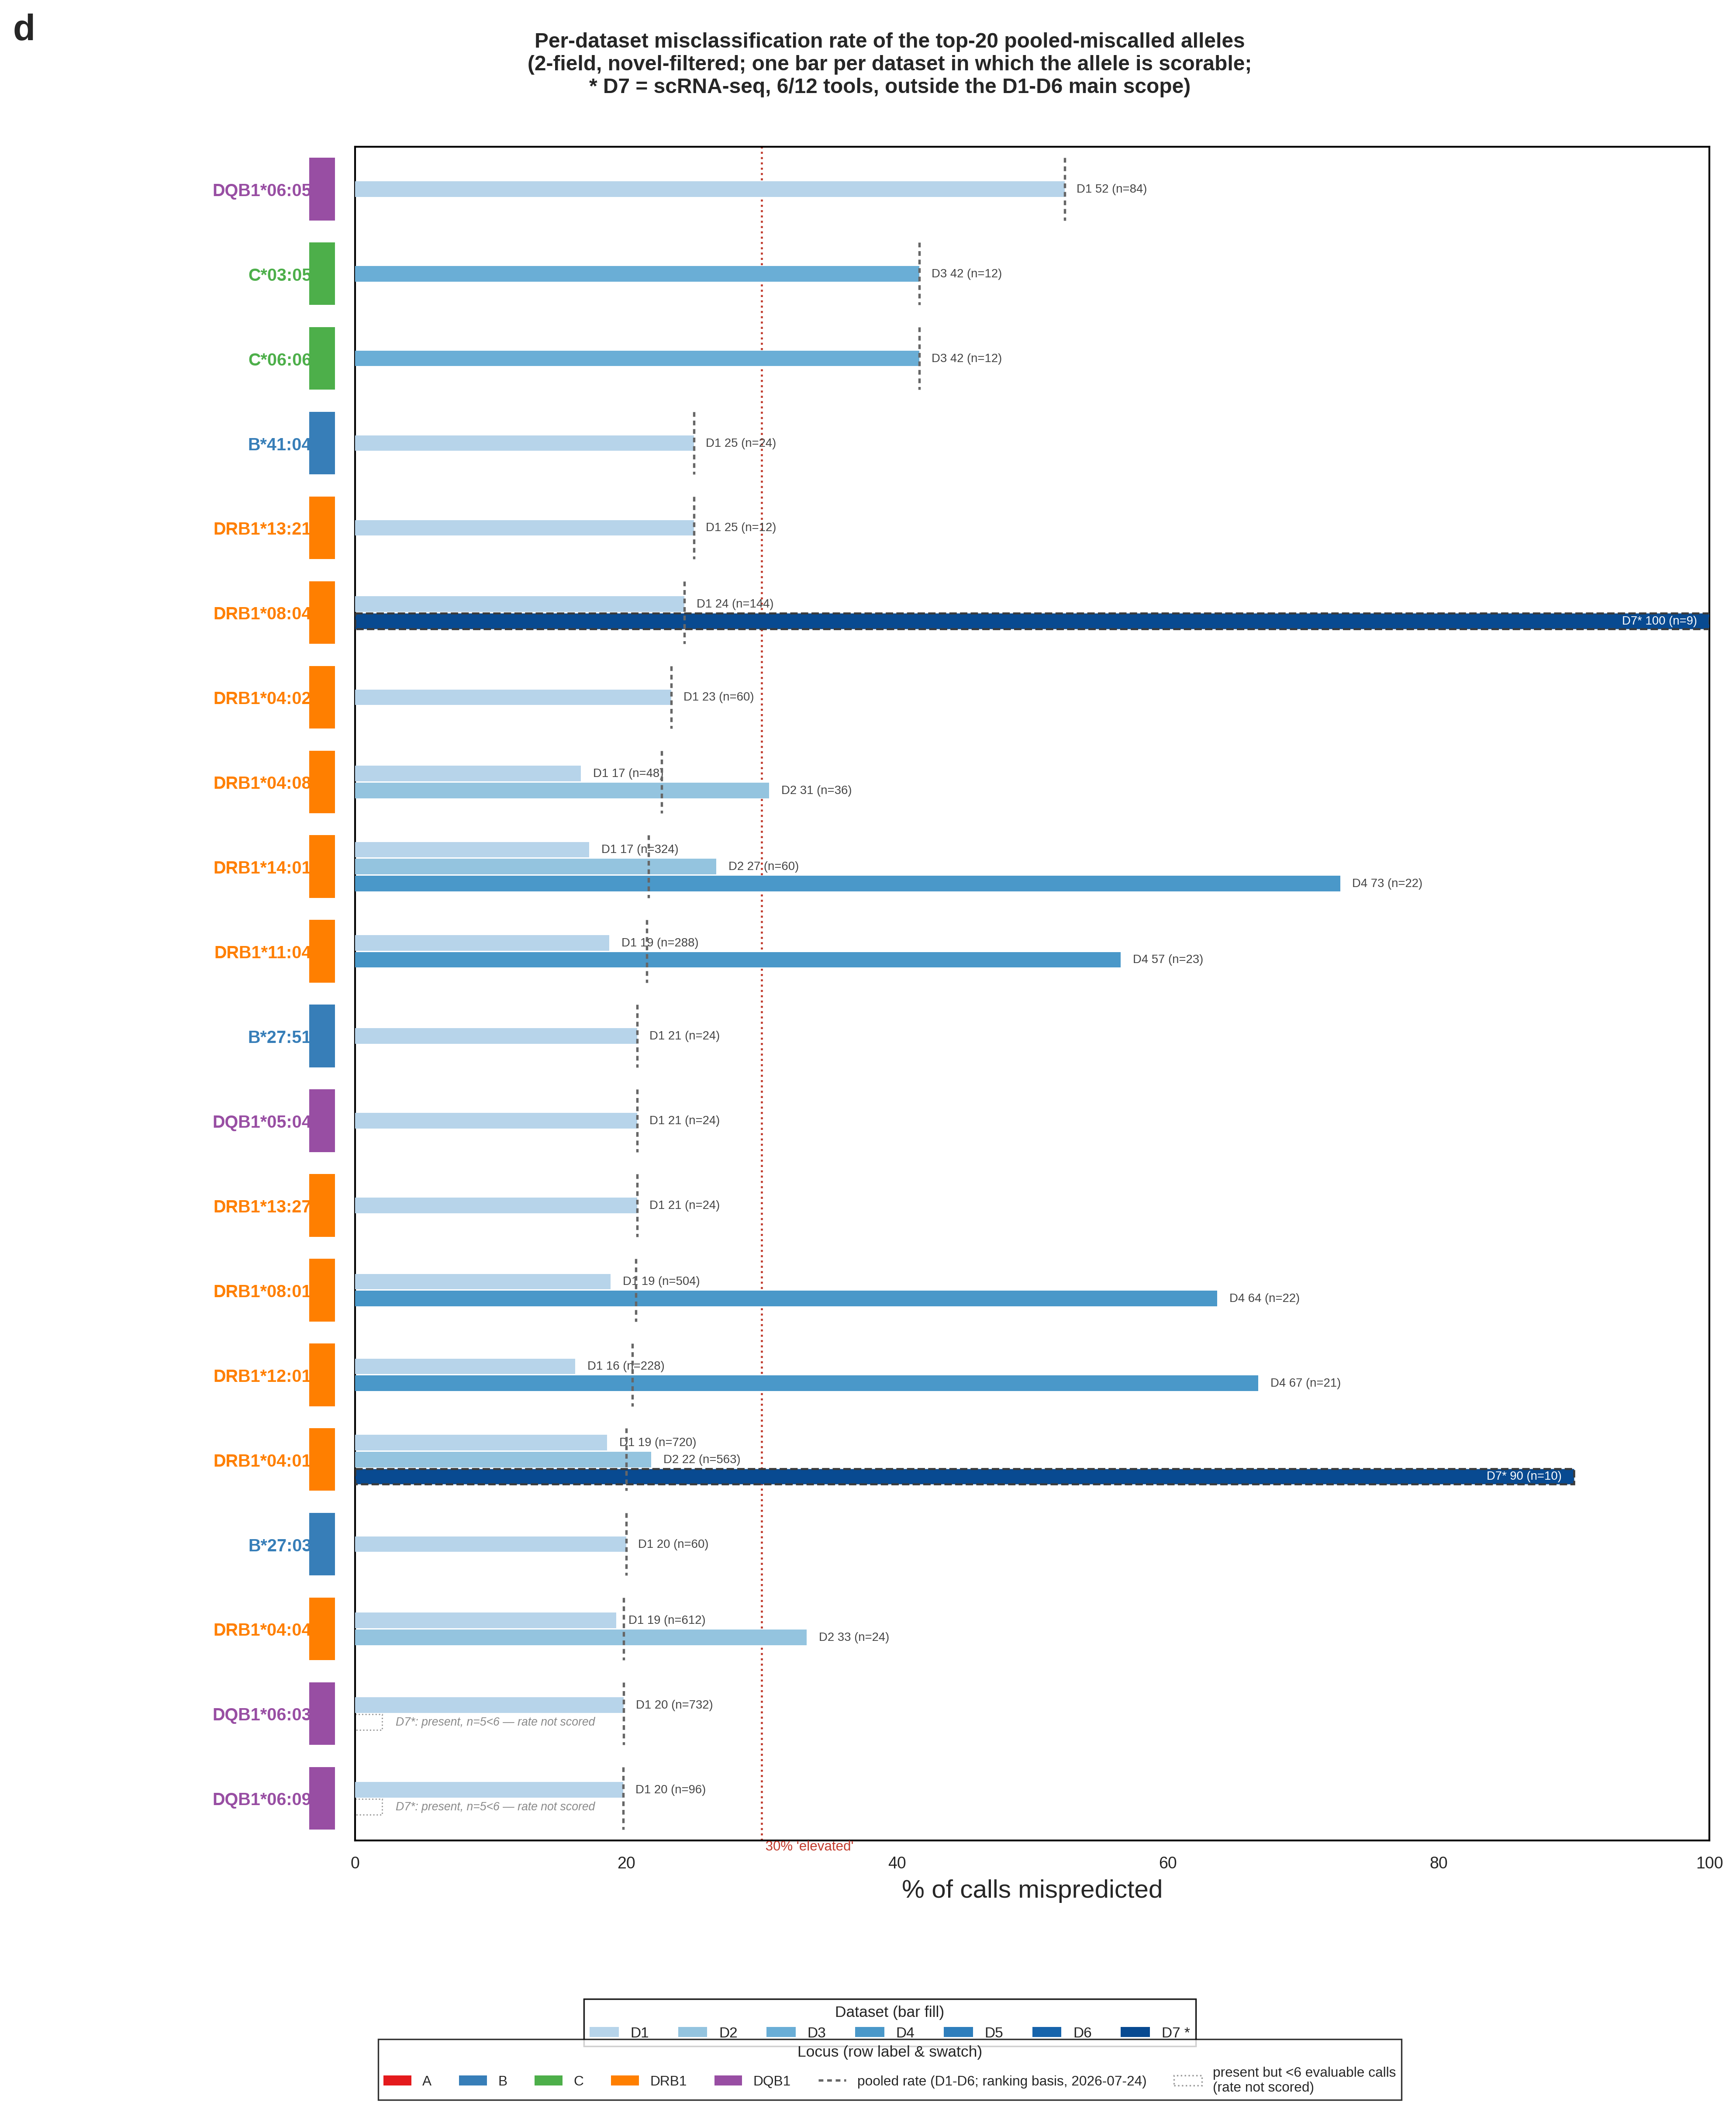

  wrote /home/nicolaedrabcinski/hla_benchmarking/repo/Figures/fig7_supp_e_slopeplot.png


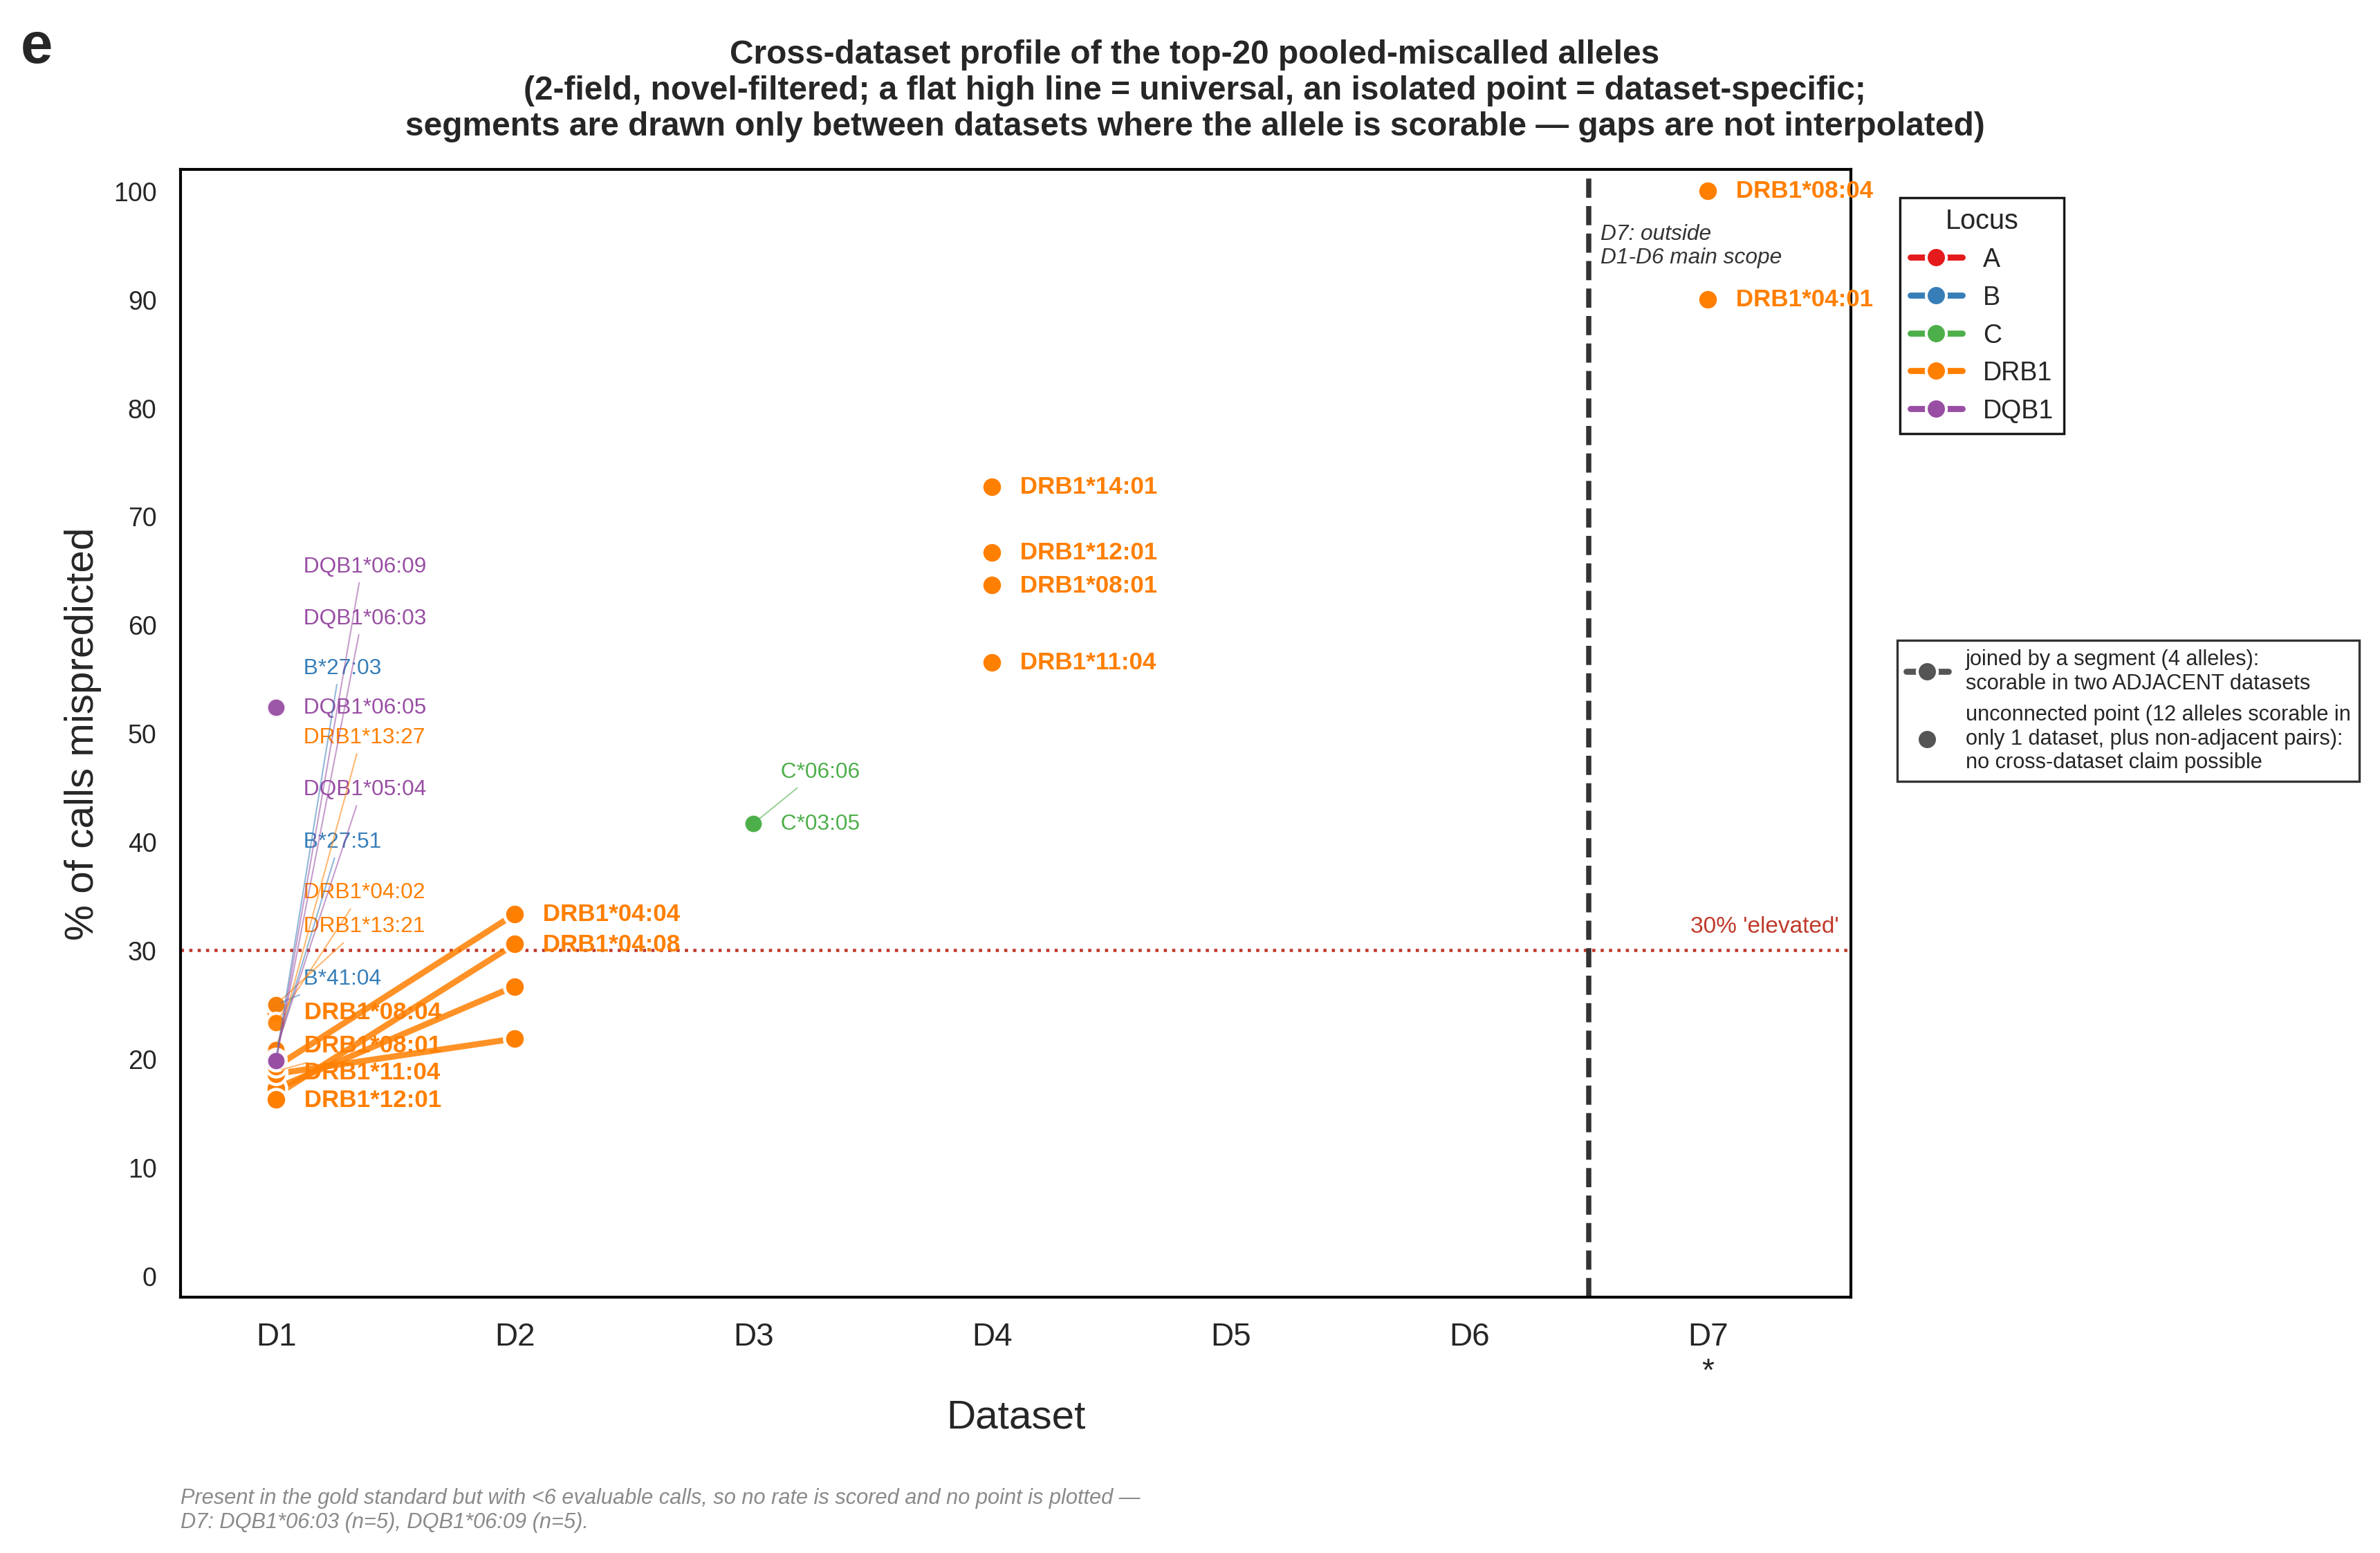

alleles scorable in >=2 datasets: 8 (DRB1*08:04, DRB1*04:08, DRB1*14:01, DRB1*11:04, DRB1*08:01, DRB1*12:01, DRB1*04:01, DRB1*04:04)
alleles scorable in exactly 1 dataset: 12


In [17]:
brk_de, order_de, locus_of_de, pooled_de = load_de()

path_d = os.path.join(FIG_DIR, "fig7_supp_d_grouped_bars.png")
plot_variant1(brk_de, order_de, locus_of_de, pooled_de, path_d)
show(path_d)

path_e = os.path.join(FIG_DIR, "fig7_supp_e_slopeplot.png")
multi, single = plot_variant2(brk_de, order_de, locus_of_de, path_e)
show(path_e)

print(f"alleles scorable in >=2 datasets: {len(multi)} ({', '.join(a for a, _ in multi)})")
print(f"alleles scorable in exactly 1 dataset: {len(single)}")


## Summary

All 5 figures (a, b, c×7, d, e) regenerated above, entirely from within this
notebook — no external `.py` script involved. The scoring/aggregation and
plotting code is now defined once, here, rather than split across four files
with several constants and helper functions previously duplicated 2-4×.